# **🚀 NASA 항공기 엔진 잔여 수명(RUL) 예측 프로젝트**

1. 도메인 지식 기반 피처 엔지니어링 (Domain-Driven Feature Engineering)
    - 물리 지표 생성: 단순 센서 수치를 넘어 압축기 온도비(LPC/HPC TR), 연료 유량(Wf) 등 엔진의 열화 상태를 민감하게 반영하는 물리 공식을 적용하여 변수를 생성했습니다.
    - 센서 이름 최적화: sensor_11과 같은 기계적 명칭을 T24 (저압 압축기 출구 온도) 등 물리적 의미가 담긴 이름으로 변경하여 분석의 해석력을 높였습니다.

2. 시계열 데이터 최적화 전처리 (Time-Series Data Preprocessing)
    - 데이터 스무딩 (Moving Average): 센서의 미세한 진동(노이즈)을 제거하기 위해 5단계 이동 평균을 적용, 엔진 상태의 장기적인 추세를 선명하게 포착했습니다.
    - 정규화 (MinMaxScaler): 단위가 다른 변수(온도, 압력 등)들을 0~1 사이로 통일하여 모델 학습의 효율성과 공정성을 확보했습니다.

3. 데이터 누수 방지 검증 전략 (Strict Validation Strategy)
    - GroupShuffleSplit 적용: 엔진 번호(unit_number)를 기준으로 데이터를 분리하여, 특정 엔진의 과거 데이터가 시험 문제에 섞여 들어가는 **데이터 누수(Data Leakage)**를 원천 차단하고 실전 성능을 보장했습니다.

4. 수치 데이터 무결성 확보 (Data Integrity)
    - 부동소수점 오차 정제 (clean_round): 연산 과정의 미세한 수치 찌꺼기를 정리하고, 무한대(inf)나 결측치를 안전하게 보정하여 학습의 정밀도를 높였습니다.

5. 머신러닝 앙상블 기법 (Ensemble Learning)
    - 7종 모델 결성: 선형 회귀, 릿지, 라쏘부터 랜덤 포레스트, XGBoost, SVR까지 서로 다른 특성을 가진 7개 알고리즘을 융합했습니다.
    - 보팅(Voting) 메커니즘: 여러 모델의 의견을 결합하여 단일 모델의 편향을 극복하고 예측의 안정성을 극대화했습니다.

6. 정밀 하이퍼파라미터 튜닝 (Hyperparameter Optimization)
    - 맞춤형 최적화: 엔진 데이터 복잡도에 맞춰 나무 깊이(max_depth), 학습률(learning_rate) 등을 미세 조정했습니다.
    - 과적합(Overfitting) 제어: 규제 계수와 샘플링 비율 설정을 통해 처음 보는 엔진 데이터에도 유연하게 대응하는 일반화 능력을 확보했습니다.

7. 성능 기반 가중치 보팅 (Performance-Based Weighted Voting)
    - 차등 투표권 부여: 검증 성능(RMSE)이 우수했던 XGBoost와 RandomForest 등 에이스 모델에 더 높은 가중치를 부여했습니다.
    - 지능적 결합: 실력이 검증된 전문가의 의견을 중시하는 전략으로 단일 모델 대비 훨씬 정교한 예측 정확도를 달성했습니다.

8. AutoML 기반 하이브리드 앙상블 (Advanced Hybrid Stacking)
    - 인공신경망(Deep Learning) 융합: 머신러닝의 수치 해석력과 딥러닝(TabularNN)의 패턴 인식 능력을 결합한 하이브리드 체계를 구축했습니다.
    - 멀티 레이어 스태킹 (Multi-layer Stacking): AutoGluon을 도입하여 수천 개의 모델 조합을 탐색하고, 모델이 서로의 오차를 보정하는 최첨단 스태킹 기법으로 성능을 한계치까지 끌어올렸습니다.

In [9]:
# [1. 도구 상자 준비]
# - 쓰임새: 데이터 분석(Pandas), 수치 계산(NumPy), 시각화(Matplotlib/Seaborn), 머신러닝 모델들을 불러옵니다.
# - 적용이유: 요리를 시작하기 전 필요한 조리 도구와 양념들을 미리 선반에 꺼내두는 작업과 같습니다.
# - 변경내용: 파이썬이 데이터 분석 및 7종의 머신러닝 알고리즘을 사용할 수 있는 상태가 됩니다.

# !pip install autogluon


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from autogluon.tabular import TabularPredictor

c:\Users\yuzhd\miniconda3\envs\DS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# [2. 데이터 로드 및 이름표 설정]
# - 쓰임새: 이름표 없는 txt 데이터를 불러오고 '엔진 번호', '가동 시간', '센서 1~21' 등의 이름을 붙여줍니다.
# - 적용이유: 원본 데이터는 숫자만 나열되어 있어, 어떤 열이 온도인지 압력인지 구분하기 위해 이름표가 필수입니다.
# - 변경내용: 단순한 텍스트 파일이 우리가 읽을 수 있는 '엑셀 형태의 표(DataFrame)'로 바뀝니다.


index_names = ['unit_number', 'time_in_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

In [11]:
# [3. 데이터 로드 및 Test RUL 생성]
# - 쓰임새: NASA Raw 데이터(FD001) 및 정답지(RUL) 로드 및 학습용 타겟 변수(RUL) 생성
# - 적용이유: 제공된 Raw 데이터에는 '잔여 수명(RUL)' 값이 직접적으로 포함되어 있지 않으므로, 
#            엔진별 최대 사이클 정보를 이용해 예측 목표인 RUL을 직접 계산해야 함
# - 변경내용: 엔진별 최대 사이클에서 현재 사이클을 빼는 'Run-to-Failure' 방식 적용 2. Test RUL: 외부 정답 파일(RUL_FD001.txt)과 
#            테스트셋의 마지막 시점을 결합하여 각 시점별 실제 남은 수명을 역산함 3. RUL Clipping: 초기 상태의 엔진 데이터가 
#            모델에 혼선을 주지 않도록 RUL의 최대치를 130으로 제한(Clipping)하여 예측 안정성 확보


train_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\train_FD001.txt", sep='\s+', header=None, names=col_names)
test_df = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\test_FD001.txt", sep='\s+', header=None, names=col_names)
true_rul = pd.read_csv(r"C:\Users\yuzhd\github\DataScience\scikit-learn\scikit-learn\data\CMaps\RUL_FD001.txt", sep='\s+', header=None, names=['Actual_RUL'])

# 각 엔진별 최대 수명(max_cycle)을 구해서 현재 수명을 뺍니다.
train_max_cycle = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
train_max_cycle.columns = ['unit_number', 'max_cycle']
train_df = train_df.merge(train_max_cycle, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop('max_cycle', axis=1, inplace=True)

# 테스트 데이터는 중간에 멈춘 데이터이므로, '멈춘 시점' + '정답 파일(RUL)'을 더해야 실제 전체 수명이 나옵니다.
# 1. 정답 파일에 엔진 번호 부여
true_rul['unit_number'] = true_rul.index + 1

# 2. Test 데이터의 엔진별 '마지막 시점(max_cycle)' 구하기
test_max_cycle = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max_cycle.columns = ['unit_number', 'max_cycle']

# 3. Test 데이터에 '실제 남은 수명(Actual_RUL)'과 '마지막 시점' 병합
test_df = test_df.merge(true_rul, on='unit_number', how='left')
test_df = test_df.merge(test_max_cycle, on='unit_number', how='left')

# 4. 각 시점별 RUL 역산 (공식: 현재 RUL = 정답RUL + (마지막시점 - 현재시점))
test_df['RUL'] = test_df['Actual_RUL'] + (test_df['max_cycle'] - test_df['time_in_cycles'])

# 5. 불필요한 임시 컬럼 삭제
test_df.drop(['Actual_RUL', 'max_cycle'], axis=1, inplace=True)

# 6. RUL 클리핑 (훈련 데이터와 동일하게 130 이상은 130으로 제한)
train_df['RUL'] = train_df['RUL'].clip(upper=130)
test_df['RUL'] = test_df['RUL'].clip(upper=130)

print("✅ Train/Test 데이터 로드 및 RUL 계산 완료!")

✅ Train/Test 데이터 로드 및 RUL 계산 완료!


In [12]:
# [4. 데이터 품질 확인 및 통계 분석]
# - 쓰임새: .head()로 상위 10개 데이터를 보고, .describe()로 평균/최솟값/최댓값 등 통계를 확인합니다.
# - 적용이유: 데이터가 깨지지는 않았는지, 혹은 값이 전혀 변하지 않는 고장 난 센서가 있는지 분석 전 '사전 검사'를 하는 과정입니다.
# - 변경내용: 분석가가 데이터의 전체적인 크기와 숫자 범위를 파악하게 됩니다.


train_df.head(10)

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,130
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,130
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,130
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,130
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,130
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669,130
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774,130
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106,130
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066,130
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694,130


In [13]:
# [5. 도메인 지식 기반 컬럼명 변경]
# - 쓰임새: 컬럼명 변경
# - 적용이유: 컬럼명 변경으로 모델의 해석력을 높임
# - 변경내용: 모델의 해석력이 높아지며, 비전공자나 현장 전문가도 이해할 수 있는 '직관적인 표'가 됩니다.


rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}

train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],RUL,condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,130,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,130,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,130,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,130,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,130,0.0_0.0_100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4,0.0_0.0_100.0
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3,0.0_0.0_100.0
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2,0.0_0.0_100.0
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1,0.0_0.0_100.0


In [14]:
# [6. 파생 변수 생성]
# - 쓰임새: 파생 변수 생성
# - 적용이유: 파생 변수 생성을 통해 모델의 성능을 향상시킴
# - 변경내용: 파생 변수 생성


def safe_div(col1, col2, new_col):
    if col1 in train_df.columns and col2 in train_df.columns:
        train_df[new_col] = train_df[col1] / train_df[col2]
        return True
    return False

# 가능한 조합들만 계산
# LPC 온도비 (T24 / T2) -> T2가 없으면 생략됨
safe_div('T24[R]', 'T2[R]', 'LPC.TR[-]')

# HPC 온도비 (T30 / T24)
safe_div('T30[R]', 'T24[R]', 'HPC.TR[-]')

# 연료 유량 (phi * Ps30)
if 'phi[pph/psi]' in train_df.columns and 'Ps30[psi]' in train_df.columns:
    train_df["Wf[pph]"] = train_df["phi[pph/psi]"] * train_df["Ps30[psi]"]

# 보정된 연료 유량 (T2[R]이 리스트에 없으므로 생략하거나 다른 값 기준)
if 'phi[pph/psi]' in train_df.columns and 'T2[R]' in train_df.columns:
    train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"] / np.sqrt(train_df["T2[R]"] / 518.67)

# 결측치 및 무한대 처리
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df = train_df.bfill().ffill()

print(f"✅ 사용 가능한 컬럼으로 파생 변수 생성을 완료했습니다!")
print(f"📊 최종 컬럼 수: {len(train_df.columns)}개")

✅ 사용 가능한 컬럼으로 파생 변수 생성을 완료했습니다!
📊 최종 컬럼 수: 32개


In [15]:
# [7. 데이터 품질 확인 및 통계 분석]
# - 쓰임새: 데이터 품질 확인 및 통계 분석
# - 적용이유: 데이터 품질 확인 및 통계 분석을 통해 모델의 성능을 향상시킴
# - 변경내용: 데이터 품질 확인 및 통계 분석


train_df.describe()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],RUL,LPC.TR[-],HPC.TR[-],Wf[pph],WfP3C[pph/psi]
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,393.210654,2388.0,100.0,38.816271,23.289705,88.727304,1.239094,2.474822,24788.438631,47.541168
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,1.548763,0.0,0.0,0.180746,0.108251,43.444137,0.000964,0.008518,111.059960,0.267087
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,388.000000,2388.0,100.0,38.140000,22.894200,0.000000,1.236258,2.444552,24479.455000,46.850000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,392.000000,2388.0,100.0,38.700000,23.221800,51.000000,1.238408,2.468961,24708.848550,47.350000
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,393.000000,2388.0,100.0,38.830000,23.297900,103.000000,1.239015,2.474444,24778.261600,47.510000
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,394.000000,2388.0,100.0,38.950000,23.366800,130.000000,1.239709,2.480312,24857.587350,47.700000
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,400.000000,2388.0,100.0,39.430000,23.618400,130.000000,1.242659,2.513266,25233.796400,48.530000


In [16]:
# [8. 결측치 및 이상치 처리]
# - 쓰임새: 데이터에 비어있는 값(NaN)이나 비정상적인 값(무한대 등)을 제거하거나 채웁니다.
# - 적용이유: 모델이 엉뚱한 값을 학습하지 않도록 데이터를 '깨끗하게' 정제하는 필수 과정입니다.
# - 변경내용: 결측치가 제거되거나 대체되어 데이터의 행 수가 줄어들거나 값이 수정됩니다.


train_df.isnull().sum()

unit_number       0
time_in_cycles    0
Alt[kft]          0
Mn[-]             0
TLA[deg]          0
T2[R]             0
T24[R]            0
T30[R]            0
T50[R]            0
P2[psi]           0
P15[psi]          0
P30[psi]          0
Nf[rpm]           0
Nc[rpm]           0
epr[-]            0
phi[pph/psi]      0
Ps30[psi]         0
NRf[rpm]          0
NRc[rpm]          0
BPR[-]            0
farB[-]           0
htBleed[]         0
Nf_dmd[rpm]       0
PCNfR_dmd[Pct]    0
W31[lbm/s]        0
W32[lbm/s]        0
RUL               0
condition         0
LPC.TR[-]         0
HPC.TR[-]         0
Wf[pph]           0
WfP3C[pph/psi]    0
dtype: int64

In [17]:
# [9. 데이터 프로파일링 및 무결성 검사]
# - 쓰임새: 학습 데이터(train_df)의 컬럼별 데이터 타입, 결측치(Null) 유무 및 비율을 요약 요약표로 생성
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.


pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df

,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%)
0,unit_number,int64,20631,0,0.0
1,time_in_cycles,int64,20631,0,0.0
2,Alt[kft],float64,20631,0,0.0
3,Mn[-],float64,20631,0,0.0
4,TLA[deg],float64,20631,0,0.0
5,T2[R],float64,20631,0,0.0
6,T24[R],float64,20631,0,0.0
7,T30[R],float64,20631,0,0.0
8,T50[R],float64,20631,0,0.0
9,P2[psi],float64,20631,0,0.0


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |

* 참고
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [18]:
# [10. 컬럼별 데이터 타입 확인]
# - 쓰임새: 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수 등을 한눈에 확인합니다.
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.


train_df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   Alt[kft]        20631 non-null  float64
 3   Mn[-]           20631 non-null  float64
 4   TLA[deg]        20631 non-null  float64
 5   T2[R]           20631 non-null  float64
 6   T24[R]          20631 non-null  float64
 7   T30[R]          20631 non-null  float64
 8   T50[R]          20631 non-null  float64
 9   P2[psi]         20631 non-null  float64
 10  P15[psi]        20631 non-null  float64
 11  P30[psi]        20631 non-null  float64
 12  Nf[rpm]         20631 non-null  float64
 13  Nc[rpm]         20631 non-null  float64
 14  epr[-]          20631 non-null  float64
 15  phi[pph/psi]    20631 non-null  float64
 16  Ps30[psi]       20631 non-null  float64
 17  NRf[rpm]        20631 non-null 

In [19]:
# [11. 데이터프레임의 컬럼 정보 확인]
# - 쓰임새: 데이터프레임의 컬럼 이름, 데이터 타입, 결측치 개수 등을 한눈에 확인합니다.
# - 적용이유: 데이터의 구조를 파악하고 결측치가 있는지 확인하여 전처리 계획을 세우는 데 도움을 줍니다.
# - 변경내용: 데이터프레임의 컬럼 정보가 요약된 표가 생성됩니다.


train_df.columns

Index(['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'TLA[deg]',
       'T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 'P15[psi]',
       'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'epr[-]', 'phi[pph/psi]', 'Ps30[psi]',
       'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 'Nf_dmd[rpm]',
       'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]', 'RUL', 'condition',
       'LPC.TR[-]', 'HPC.TR[-]', 'Wf[pph]', 'WfP3C[pph/psi]'],
      dtype='object')

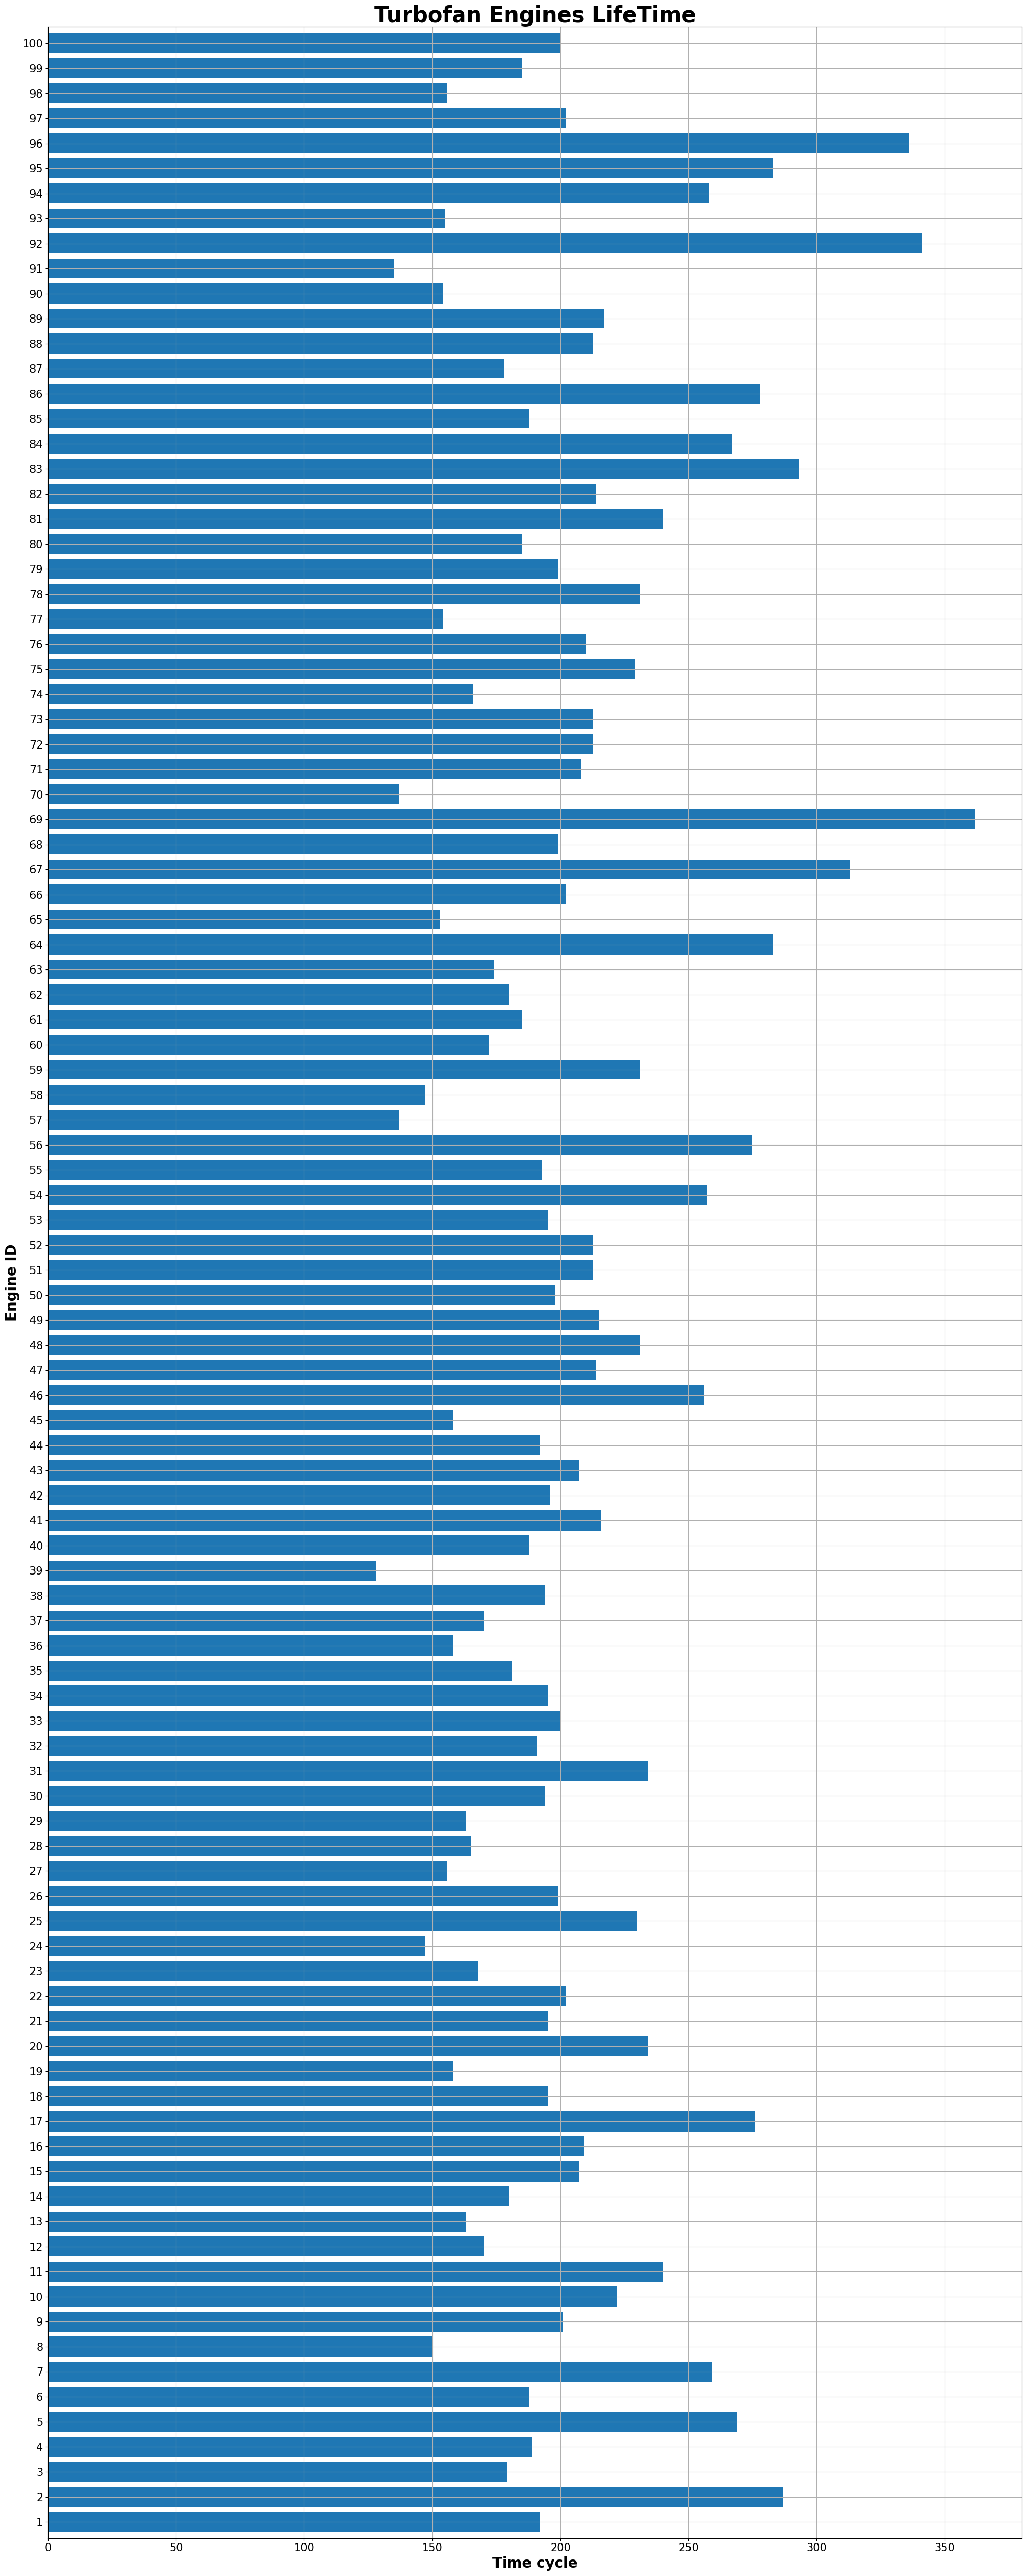

In [20]:
# [12. 엔진별 수명 시각화]
# - 쓰임새: 각 엔진이 최대 몇 사이클까지 작동했는지 시각적으로 확인합니다.
# - 적용이유: 데이터셋에 포함된 엔진들의 수명 분포를 파악하여, 조기 고장 엔진이 있는지, 수명이 다한 엔진이 있는지 확인합니다.
# - 변경내용: 가로 막대 그래프가 생성되어 엔진 번호와 최대 작동 사이클이 표시됩니다.


max_time_cycles=train_df[['unit_number','time_in_cycles']].groupby('unit_number').max()
plt.figure(figsize=(20,50))
ax=max_time_cycles['time_in_cycles'].plot(kind='barh',width=0.8, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Time cycle',fontweight='bold',size=20)
plt.xticks(size=15)
plt.ylabel('Engine ID',fontweight='bold',size=20)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 9.444444444444459, 'max time in cycles')

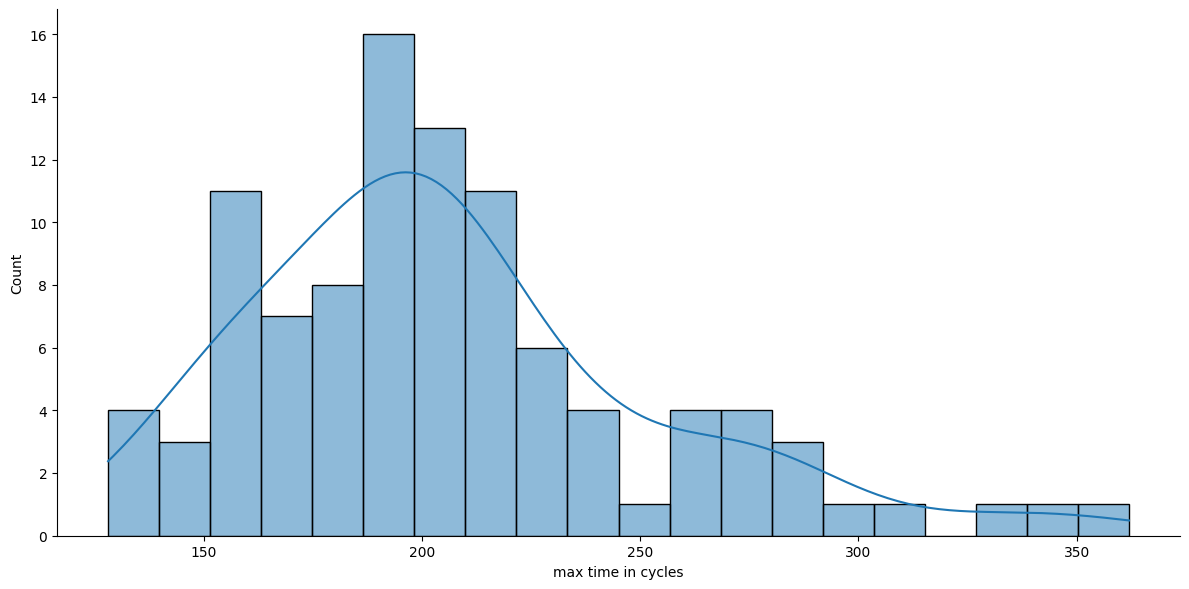

In [21]:
# [13. 최대 작동 사이클 분포 시각화]
# - 쓰임새: 전체 엔진들의 최대 작동 사이클이 어떤 분포를 이루는지 확인합니다.
# - 적용이유: 데이터셋에 포함된 엔진들의 수명 분포를 파악하여, 조기 고장 엔진이 있는지, 수명이 다한 엔진이 있는지 확인합니다.
# - 변경내용: 히스토그램과 커널 밀도 추정(KDE) 곡선이 함께 표시된 그래프가 생성됩니다.


sns.displot(max_time_cycles['time_in_cycles'],kde=True,bins=20,height=6,aspect=2)
plt.xlabel('max time in cycles')

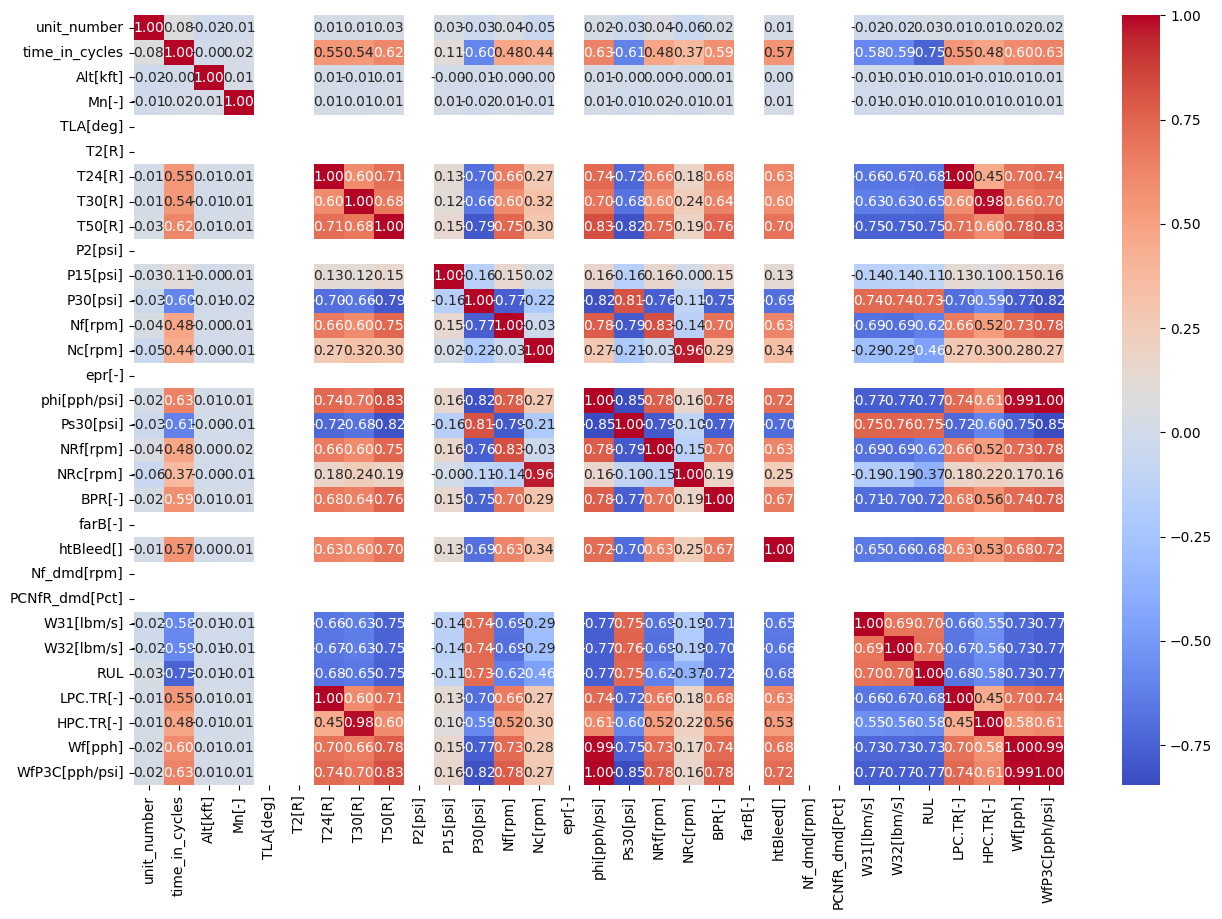

In [22]:
# [14. 상관관계 히트맵 시각화]
# - 쓰임새: 데이터프레임 내 모든 수치형 컬럼 간의 상관관계를 시각적으로 확인합니다.
# - 적용이유: 어떤 센서들이 서로 관련이 있는지, 또는 특정 센서가 엔진 수명과 얼마나 관련이 있는지 파악하여 피처 엔지니어링이나 모델링에 활용할 수 있습니다.
# - 변경내용: 색상으로 표현된 상관관계 행렬(히트맵)이 생성됩니다.


plt.figure(figsize=(15, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [23]:
# [15. RUL 컬럼 생성]
# - 쓰임새: 학습 데이터셋의 각 시점(Cycle)별로 엔진이 고장 날 때까지 남은 수명(RUL, Remaining Useful Life)을 계산하여 종속 변수로 설정
# - 적용 이유: NASA 센서 데이터의 특성상 고장 시점까지의 기록은 있으나 '남은 수명'이라는 직접적인 정답지가 없으므로, 회귀 분석 학습을 위해 
#             각 행마다 대응하는 정답(Target) 데이터가 반드시 필요함
# - 변경 내용: 1. 엔진 유닛별로 데이터의 마지막 시점을 max_cycle로 정의 
#             2. 전체 엔진 수명에서 현재 작동 사이클을 빼는 역산 방식을 통해 각 시점별 잔여 수명 도출 
#             3. 모델이 예측해야 할 기준값인 RUL 컬럼을 생성하여 지도 학습(Supervised Learning)의 기반 마련


# 엔진(unit_number)별로 가장 큰 사이클 번호를 찾습니다.
max_cycle = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

# 원본 데이터에 최대 수명 정보를 합칩니다.
train_df = train_df.merge(max_cycle, on='unit_number', how='left')

# RUL = 최대 수명 - 현재 사이클
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

# 사용이 끝난 max_cycle 컬럼은 삭제합니다.
train_df.drop('max_cycle', axis=1, inplace=True)

print("RUL 컬럼 생성 완료!")
train_df[['unit_number', 'time_in_cycles', 'RUL']].head()

RUL 컬럼 생성 완료!


,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


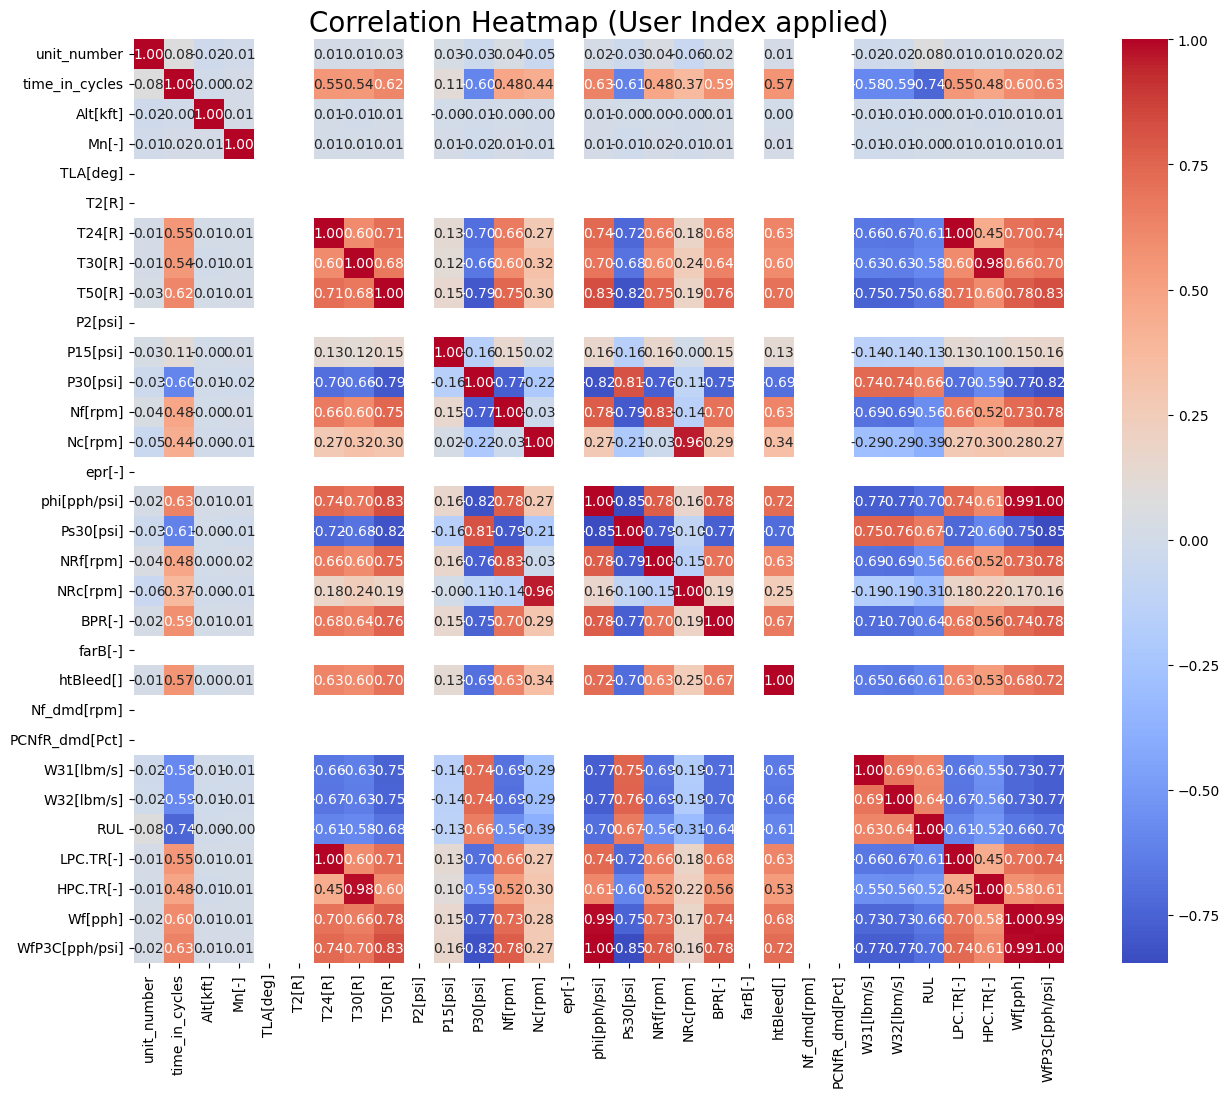

--- RUL과 상관관계가 높은 순서 ---
RUL               1.000000
Ps30[psi]         0.671983
P30[psi]          0.657223
W32[lbm/s]        0.635662
W31[lbm/s]        0.629428
unit_number       0.078753
Mn[-]            -0.001948
Alt[kft]         -0.003198
P15[psi]         -0.128348
NRc[rpm]         -0.306769
Nc[rpm]          -0.390102
HPC.TR[-]        -0.517380
NRf[rpm]         -0.562569
Nf[rpm]          -0.563968
T30[R]           -0.584520
htBleed[]        -0.606154
LPC.TR[-]        -0.606484
T24[R]           -0.606484
BPR[-]           -0.642667
Wf[pph]          -0.660278
T50[R]           -0.678948
phi[pph/psi]     -0.696228
WfP3C[pph/psi]   -0.696228
time_in_cycles   -0.736241
TLA[deg]               NaN
T2[R]                  NaN
P2[psi]                NaN
epr[-]                 NaN
farB[-]                NaN
Nf_dmd[rpm]            NaN
PCNfR_dmd[Pct]         NaN
Name: RUL, dtype: float64


In [24]:
# [16. 상관관계 계산 (숫자 데이터만!)]
# - 쓰임새: 데이터프레임 내 모든 수치형 컬럼 간의 상관관계를 시각적으로 확인합니다.
# - 적용이유: 어떤 센서들이 서로 관련이 있는지, 또는 특정 센서가 엔진 수명과 얼마나 관련이 있는지 파악하여 피처 엔지니어링이나 모델링에 활용할 수 있습니다.
# - 변경내용: 색상으로 표현된 상관관계 행렬(히트맵)이 생성됩니다.


plt.figure(figsize=(15, 12))

# RUL과 센서들 간의 상관관계만 뽑아서 보기 좋게 정렬합니다.
correlations = train_df.corr(numeric_only=True)['RUL'].sort_values(ascending=False)

# 히트맵 그리기
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (User Index applied)', fontsize=20)
plt.show()

print("--- RUL과 상관관계가 높은 순서 ---")
print(correlations)

In [25]:
# [17. 무의미한 피처(Feature) 선별 및 제거]
# - 쓰임새: 센서 데이터 중 모든 엔진에서 값이 동일하거나 변화가 거의 없어, 수명 예측에 도움이 되지 않는 불필요한 변수들을 식별하고 삭제함
# - 적용 이유: 값이 변하지 않는 컬럼(분산이 0인 데이터)은 모델 학습 과정에서 노이즈로 작용하며, 불필요한 계산량을 늘려 모델의 복잡도만 높이고 
#             예측 성능(일반화 성능)을 저하시킬 수 있기 때문임
# - 변경 내용: 1. nunique() 함수를 사용하여 유니크한 값이 1개 이하인 상수(Constant) 컬럼을 자동으로 추출함 
#             2. 데이터 분석 결과 수명 변화와 상관관계가 없는 특정 센서(sensor_6, op_setting_3)를 추가로 선정하여 삭제 리스트에 포함함 
#             3. 최종적으로 최적화된 피처들만 남겨 모델이 엔진의 열화 패턴에만 집중할 수 있는 환경을 구축함


# 값이 변하지 않는(분산이 0인) 무의미한 컬럼 자동 추출
constant_columns = [col for col in train_df.columns if train_df[col].nunique() <= 1]

# 자동으로 찾은 고정값 컬럼에 'sensor_6'와 'op_setting_3'를 추가
cols_to_drop = list(set(constant_columns + ['sensor_6', 'op_setting_3']))

# 데이터프레임에서 불필요한 컬럼 삭제 실행
train_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f"❌ 삭제된 컬럼 목록: {cols_to_drop}")
print(f"✅ 남은 컬럼 개수: {len(train_df.columns)}개")
print(f"📊 현재 컬럼 목록: {train_df.columns.tolist()}")

❌ 삭제된 컬럼 목록: ['PCNfR_dmd[Pct]', 'Nf_dmd[rpm]', 'epr[-]', 'sensor_6', 'op_setting_3', 'T2[R]', 'TLA[deg]', 'condition', 'P2[psi]', 'farB[-]']
✅ 남은 컬럼 개수: 24개
📊 현재 컬럼 목록: ['unit_number', 'time_in_cycles', 'Alt[kft]', 'Mn[-]', 'T24[R]', 'T30[R]', 'T50[R]', 'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 'phi[pph/psi]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 'htBleed[]', 'W31[lbm/s]', 'W32[lbm/s]', 'RUL', 'LPC.TR[-]', 'HPC.TR[-]', 'Wf[pph]', 'WfP3C[pph/psi]']


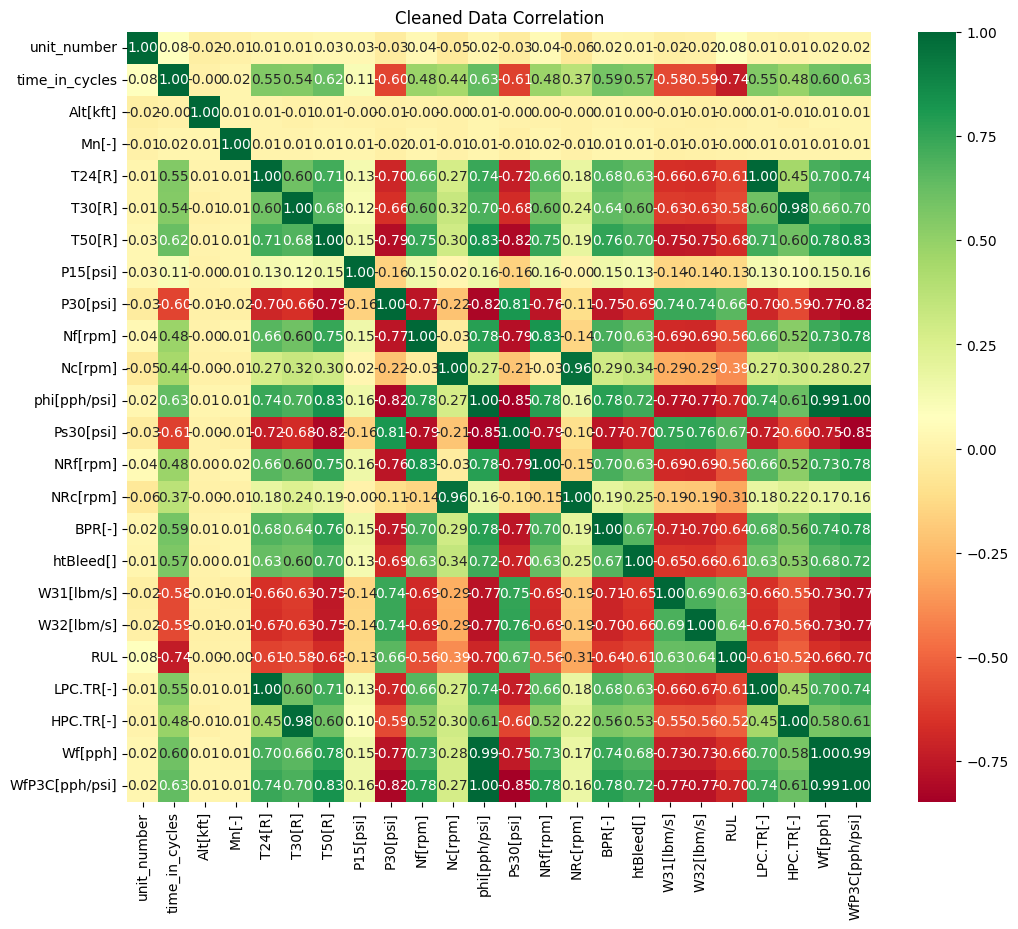

In [26]:
# [18. 데이터 정제 - 노이즈 변수 및 오차 제거]
# - 쓰임새: 값이 변하지 않는 상수 컬럼(표준편차 0)을 삭제하고, 컴퓨터 연산 오차(부동소수점)를 다듬습니다.
# - 적용 이유: 변하지 않는 값은 학습에 도움이 안 되고 계산 속도만 늦추기 때문입니다.
# - 변경 내용: 학습 효율이 떨어지는 불필요한 데이터가 삭제되어 데이터가 가벼워지고 깨끗해집니다.

plt.figure(figsize=(12, 10))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Cleaned Data Correlation")
plt.show()

In [27]:
# [19. 시계열 윈도우 통계 피처 생성 (Rolling Statistics)]
# - 쓰임새: 주요 센서 데이터에 대해 5개 사이클 단위의 이동 평균(Average), 표준편차(Std), 변화량(Difference) 파생 변수를 생성함
# - 적용 이유: 센서 데이터의 순간적인 노이즈를 제거하고, 최근 5개 사이클 동안의 데이터 경향성(추세)을 파악하여 모델이 엔진의 열화 상태를 더 정확하게 인지하도록 돕기 위함
# - 변경 내용: 원본 센서 데이터 옆에 이동 평균, 표준편차, 변화량 파생 변수 컬럼이 추가됨


# 분석 대상 센서 리스트 (상관관계가 높았던 주요 센서들)
main_sensors = [
    'T24[R]', 'T30[R]', 'T50[R]', 'P30[psi]', 'Nf[rpm]', 
    'Nc[rpm]', 'Ps30[psi]', 'NRf[rpm]', 'NRc[rpm]', 'BPR[-]', 
    'W31[lbm/s]', 'W32[lbm/s]'
]

window_size = 5

# 5개 사이클씩 묶어서 평균 계산 (이동 평균)
for s in main_sensors:
    if s in train_df.columns:
        # A. 이동 평균 (Moving Average)
        train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
        # B. 표준편차 (Rolling Std)
        train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())
        # C. 변화량 (Difference)
        train_df[f'{s}_diff'] = train_df.groupby('unit_number')[s].transform(lambda x: x.diff(periods=window_size))

# 결측치 처리 (NaN 제거)
train_df = train_df.bfill()

print("✅ 평균(_avg), 표준편차(_std), 기울기(_diff) 생성 및 결측치 처리 완료!")

✅ 평균(_avg), 표준편차(_std), 기울기(_diff) 생성 및 결측치 처리 완료!


In [28]:
# [20. 성능 저하 누적량(Performance Degradation) 산출]
# - 쓰임새: 엔진 유닛별로 가동 시작 이후 기록된 센서의 최댓값(최상 상태)과 현재 수치의 차이를 계산하여 성능 저하 지표 생성
# - 적용 이유: 엔진은 가동 시간이 길어질수록 주요 센서 수치가 초기 성능에서 벗어나는 열화 현상이 발생함. 현재 수치 자체보다 
#             '최상의 상태에서 얼마나 멀어졌는가'라는 상대적 거리가 잔여 수명(RUL)과 더 강한 상관관계를 가지기 때문임
# - 변경 내용: 1. cummax() 함수를 사용하여 엔진별 누적 최댓값(Best Performance)을 실시간으로 추적 
#             2. 최댓값과 현재값의 차이를 _diff 변수로 생성하여 누적 성능 저하량을 수치화 
#             3. bfill()을 통해 계산 초기 단계의 결측치를 보정하여 데이터의 완전성 확보


# "가장 좋았을 때보다 얼마나 변했나?" 계산
for sensor in main_sensors:
    if sensor in train_df.columns:
        # 현재까지의 최대값 찾기
        cum_max = train_df.groupby('unit_number')[sensor].cummax()
        # 최대값과 현재값의 차이 계산
        train_df[f'{sensor}_diff'] = cum_max - train_df[sensor]

# 앞부분에 생기는 빈칸(NaN) 채우기
train_df = train_df.infer_objects(copy=False).fillna(method='bfill')

print("✅ 성능 변화량(_diff) 변수 생성 완료!")
print(train_df.head())

✅ 성능 변화량(_diff) 변수 생성 완료!
   unit_number  time_in_cycles  Alt[kft]   Mn[-]  T24[R]   T30[R]   T50[R]  \
0            1               1   -0.0007 -0.0004  641.82  1589.70  1400.60   
1            1               2    0.0019 -0.0003  642.15  1591.82  1403.14   
2            1               3   -0.0043  0.0003  642.35  1587.99  1404.20   
3            1               4    0.0007  0.0000  642.35  1582.79  1401.87   
4            1               5   -0.0019 -0.0002  642.37  1582.85  1406.22   

   P15[psi]  P30[psi]  Nf[rpm]  ...  NRc[rpm]_diff  BPR[-]_avg  BPR[-]_std  \
0     21.61    554.36  2388.06  ...           0.00     8.41334    0.025953   
1     21.61    553.75  2388.04  ...           7.13     8.41334    0.025953   
2     21.61    554.26  2388.08  ...           5.39     8.41334    0.025953   
3     21.61    554.45  2388.11  ...           4.79     8.41334    0.025953   
4     21.61    554.00  2388.06  ...           4.82     8.41334    0.025953   

   BPR[-]_diff  W31[lbm/s]_avg  W31[

C:\Users\yuzhd\AppData\Local\Temp\ipykernel_37252\3466659243.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.infer_objects(copy=False).fillna(method='bfill')


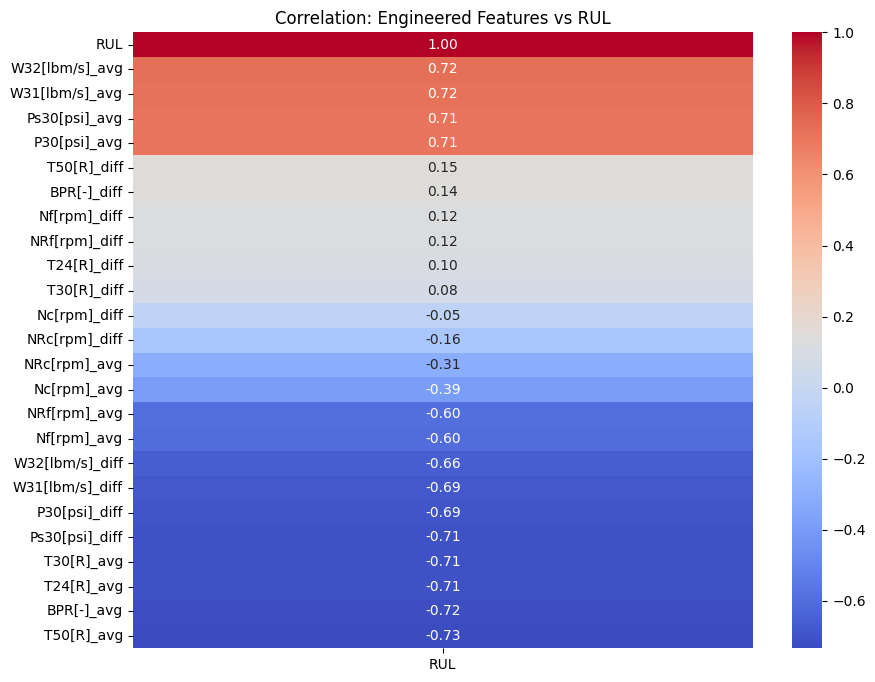

In [29]:
# [21. 피처 엔지니어링 결과 시각화 및 상관관계 분석]
# - 쓰임새: 새로 만든 '평균(avg)'과 '변화량(diff)' 피처가 실제로 RUL과 얼마나 관련이 있는지 시각적으로 확인합니다.
# - 적용 이유: 상관관계가 높을수록 해당 피처가 고장 예측에 유용하다는 뜻이므로, 모델 학습 시 우선순위를 높일 수 있습니다.
# - 변경 내용: 히트맵을 통해 어떤 센서의 어떤 변화가 고장과 밀접한지 한눈에 파악할 수 있습니다.


new_cols = [col for col in train_df.columns if '_avg' in col or '_diff' in col] + ['RUL']
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[new_cols].corr(numeric_only=True)[['RUL']].sort_values(by='RUL', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Engineered Features vs RUL")
plt.show()

In [30]:
# [22. 파생 변수 통계적 특성 검토]
# - 쓰임새: 새로 만든 피처들의 분포와 중심 경향성을 확인합니다.
# - 적용 이유: 평균, 표준편차, 최소/최대값 등을 통해 데이터의 특성을 파악하고, 스케일링이나 이상치 탐지의 기초 자료로 활용합니다.
# - 변경 내용: describe() 메서드를 사용하여 요약 통계량을 출력합니다.


train_df[new_cols].describe()

,T24[R]_avg,T24[R]_diff,T30[R]_avg,T30[R]_diff,T50[R]_avg,T50[R]_diff,P30[psi]_avg,P30[psi]_diff,Nf[rpm]_avg,Nf[rpm]_diff,...,NRf[rpm]_diff,NRc[rpm]_avg,NRc[rpm]_diff,BPR[-]_avg,BPR[-]_diff,W31[lbm/s]_avg,W31[lbm/s]_diff,W32[lbm/s]_avg,W32[lbm/s]_diff,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,642.668087,0.580184,1590.373861,7.696182,1408.672594,7.160707,553.392204,1.511897,2388.094904,0.056491,...,0.056608,8143.459273,6.976453,8.441129,0.038046,38.821149,0.340436,23.292580,0.204149,107.807862
std,0.409755,0.336973,4.851395,4.437970,8.021749,4.486557,0.786760,0.871978,0.063989,0.034600,...,0.034962,18.070825,5.363259,0.032036,0.022770,0.152360,0.184717,0.091513,0.110087,68.880990
min,641.616000,0.000000,1576.244000,0.000000,1390.278000,0.000000,550.810000,0.000000,2387.954000,0.000000,...,0.000000,8103.466000,0.000000,8.367020,0.000000,38.326000,0.000000,23.011400,0.000000,0.000000
25%,642.366000,0.340000,1586.876000,4.515000,1402.644000,3.790000,552.936000,0.900000,2388.046000,0.030000,...,0.030000,8133.368000,3.220000,8.416800,0.021200,38.730000,0.210000,23.238880,0.127400,51.000000
50%,642.624000,0.570000,1589.756000,7.610000,1407.704000,7.040000,553.460000,1.380000,2388.092000,0.060000,...,0.060000,8140.482000,6.350000,8.437680,0.037700,38.838000,0.320000,23.301560,0.191900,103.000000
75%,642.918000,0.810000,1593.179000,10.760000,1413.481000,10.250000,553.996000,2.000000,2388.134000,0.080000,...,0.080000,8147.788000,9.650000,8.459960,0.053700,38.934000,0.450000,23.360620,0.269100,155.000000
max,644.020000,1.870000,1608.070000,25.980000,1432.984000,25.990000,555.174000,5.180000,2388.326000,0.210000,...,0.200000,8281.152000,43.730000,8.542420,0.129800,39.186000,1.210000,23.507160,0.694200,361.000000


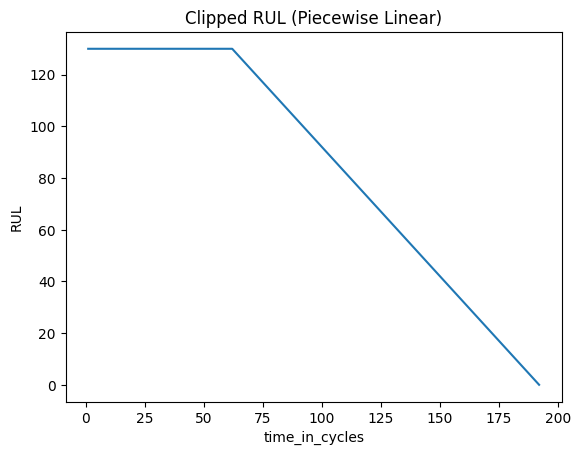

In [31]:
# [23. RUL 클리핑 (Piecewise Linear)]
# - 쓰임새: RUL의 최대값을 특정 값(예: 130)으로 제한하여 모델이 초반에 헷갈리지 않게 합니다.
# - 적용 이유: 실제 비행 데이터에서는 고장 직전까지 RUL이 거의 선형적으로 감소하다가 마지막에 급격히 떨어지는 경향이 있습니다. 이를 모델에 반영하기 위해 일정 주기 이상은 최대값으로 고정합니다.
# - 변경 내용: apply 함수를 사용하여 RUL 값이 130보다 크면 130으로 변경


train_df['RUL'] = train_df['RUL'].apply(lambda x: 130 if x > 130 else x)

sns.lineplot(data=train_df[train_df['unit_number']==1], x='time_in_cycles', y='RUL')
plt.title("Clipped RUL (Piecewise Linear)")
plt.show()

In [32]:
# [24. 심화 피처 엔지니어링: 변화율 및 센서 간 상호작용 추출]
# - 쓰임새: 센서 데이터의 노이즈를 줄이고(이동 평균), 변화 추세(변화량)와 센서 간의 관계(상호작용)를 파악합니다.
# - 적용 이유: 엔진의 노후화는 단일 센서의 변화보다 여러 지표의 비정상적인 비율 변화에서 더 뚜렷하게 나타남. 
#             특히 온도와 압력의 관계를 수치화하여 엔진 효율 저하를 정밀하게 포착하기 위함
# - 변경 내용: 1. 기울기(Gradient): 단순 차이를 넘어 '열화 가속도'를 측정하기 위한 _diff 변수 생성
#             2. 상호작용 피처(T24_P30_ratio): 온도($T24$)를 압력($P30$)으로 나눈 비율 변수를 생성하여 엔진 압축 효율성 저하 패턴을 모델에 주입
#             3. 자동화 로직: 제외 목록(exclude_cols)을 제외한 모든 유효 센서에 대해 통계 지표 생성을 자동화하여 데이터 풍부성 극대화


exclude_cols = ['unit_number', 'time_in_cycles', 'condition', 'RUL']

# 현재 데이터프레임에서 실제 센서 컬럼들만 리스트로 만듭니다.
# (숫자형 데이터이면서 제외 목록에 없는 컬럼만 추출)
# 계산 대상 센서 리스트 (기존 변수 활용)
actual_sensors = [c for c in train_df.columns if c in col_names and c not in index_names + setting_names]

window_size = 5

for s in actual_sensors:
    # (기존) 이동 평균 및 표준편차
    train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
    train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())
    
    # (추가 1) 기울기(Gradient): 5사이클 전과 현재의 차이
    # "얼마나 빨리 변하고 있는가"를 측정합니다.
    train_df[f'{s}_diff'] = train_df.groupby('unit_number')[s].transform(lambda x: x.diff(periods=window_size))

# (추가 2) 상호작용(Interaction): 온도(T24)와 압력(P30)의 비율
# 엔진의 효율 저하를 더 민감하게 포착합니다. (컬럼명이 존재할 경우에만 생성)
if 'T24[R]' in train_df.columns and 'P30[psi]' in train_df.columns:
    train_df['T24_P30_ratio'] = train_df['T24[R]'] / (train_df['P30[psi]'] + 1e-9)

# 결측치 채우기
train_df = train_df.bfill()

print(f"✅ 모든 센서에 대한 이동 평균(_avg) 변수 생성 완료!")
print(f"현재 총 컬럼 수: {len(train_df.columns)}개")

✅ 모든 센서에 대한 이동 평균(_avg) 변수 생성 완료!
현재 총 컬럼 수: 61개


In [33]:
# [25. Test 데이터 피처 엔지니어링 동기화]
# - 쓰임새: 학습 데이터(train_df)에서 생성했던 이동 평균, 표준편차, 변화량 및 상호작용 피처들을 테스트 데이터(test_df)에도 동일하게 적용
# - 적용 이유: 머신러닝 모델은 학습 시 사용된 피처의 개수와 종류가 테스트 시에도 완벽하게 일치해야 예측이 가능함. 또한, 테스트 셋의 노이즈를 제거하고 
#             동일한 '물리적 통찰력(온도/압력 비율 등)'을 제공하여 예측의 일관성을 유지하기 위함
# - 변경 내용: 1. 학습-테스트 일관성: window_size=5를 유지하여 학습 시와 동일한 시계열 추세를 추출 
#             2. 동일 로직 복제: _avg, _std, _diff 및 T24_P30_ratio 변수를 생성하여 모델이 배운 패턴을 시험 데이터에서도 인식 가능하도록 구성 
#             3. 무결성 유지: bfill()을 통해 계산 과정에서 발생한 초기 결측치를 보정하여 데이터 손실 방지


# train_df에 적용했던 것과 똑같은 로직을 test_df에도 수행해야 합니다.
for s in actual_sensors:
    # 이동 평균 및 표준편차
    test_df[f'{s}_avg'] = test_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
    test_df[f'{s}_std'] = test_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())
    # 변화량
    test_df[f'{s}_diff'] = test_df.groupby('unit_number')[s].transform(lambda x: x.diff(periods=window_size))

if 'T24[R]' in test_df.columns and 'P30[psi]' in test_df.columns:
    test_df['T24_P30_ratio'] = test_df['T24[R]'] / (test_df['P30[psi]'] + 1e-9)

# 결측치 채우기
test_df = test_df.bfill()
print("✅ Test 데이터 피처 엔지니어링 완료")

✅ Test 데이터 피처 엔지니어링 완료


In [34]:
# [26. 최종 학습 피처(Feature) 선별 및 확정]
# - 쓰임새: 전체 데이터프레임에서 모델의 학습 입력값으로 사용될 독립 변수(Feature) 리스트를 최종적으로 선별함
# - 적용 이유: 엔진 번호(unit_number)나 현재 시간(time_in_cycles)은 엔진의 물리적 상태와 직접적인 상관이 없으며, 
#             특히 정답인 RUL은 학습 시 포함될 경우 **데이터 누수(Data Leakage)**를 일으켜 모델의 성능을 가짜로 높이기 때문에 반드시 제외해야 함
# - 변경 내용: 1. 제외 리스트(exclude) 설정: 물리적 의미가 없거나 정답 정보를 포함한 컬럼들을 명확히 정의 
#             2. 필터링 로직 적용: 원본 센서 데이터와 우리가 생성한 파생 변수(이동 평균, 기울기, 상호작용 등)들만 모아 target_sensors 리스트로 통합 
#             3. 입력 차원 확정: 모델이 학습해야 할 데이터의 규격을 최종 확인하여 안정적인 학습 환경 조성


# 원본 센서들 + 이동평균 센서들만 리스트로 만들기 : 'unit_number', 'time_in_cycles', 'RUL' 처럼 공부하면 안 되는 것들을 제외합니다.
exclude = ['unit_number', 'time_in_cycles', 'RUL', 'condition']
target_sensors = [c for c in train_df.columns if c not in exclude]

print(f"✅ 모델이 공부할 총 변수 개수: {len(target_sensors)}개")

✅ 모델이 공부할 총 변수 개수: 58개


C:\Users\yuzhd\AppData\Local\Temp\ipykernel_37252\2812734056.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]_avg'].fillna(method='bfill'), label='Moving Average', color='red', linewidth=2)


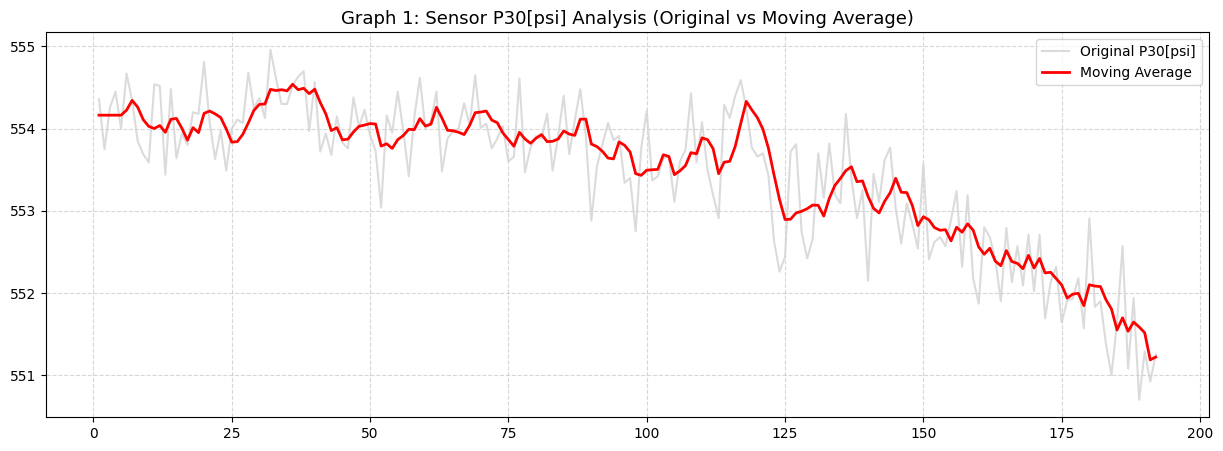

C:\Users\yuzhd\AppData\Local\Temp\ipykernel_37252\2812734056.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]_avg'].fillna(method='bfill'), label='Moving Average', color='blue', linewidth=2)


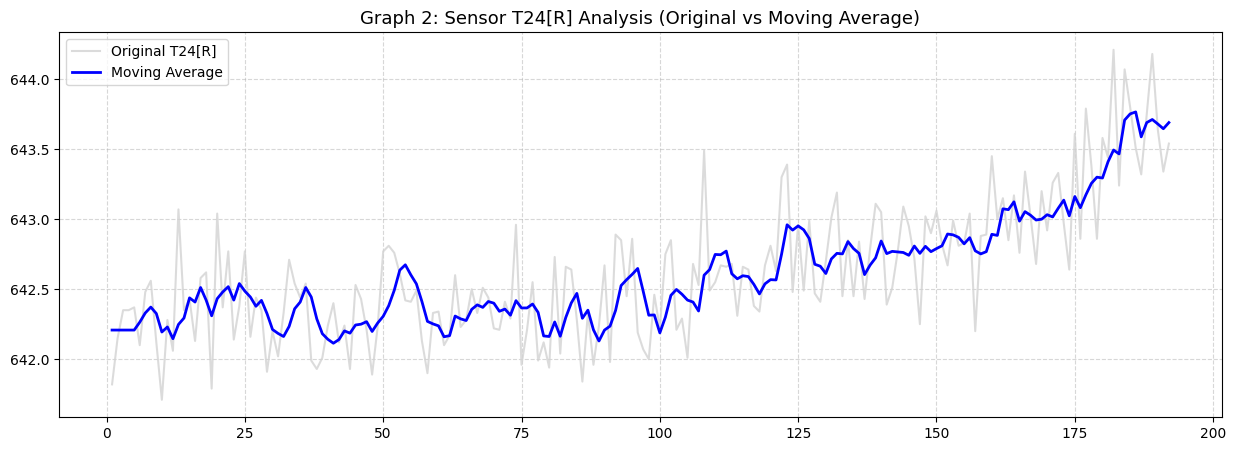

In [35]:
# [27. 전처리 효과 시각화 검증: 노이즈 제거 확인]
# - 쓰임새: 특정 엔진(unit_number == 1)을 샘플링하여, 원본 센서 데이터와 이동 평균(Moving Average) 처리가 완료된 데이터를 시각적으로 대조함
# - 적용 이유: 센서 고유의 미세한 진동(노이즈)이 제거되었는지 확인하고, 엔진 작동 시간이 경과함에 따라 수치가 상승하거나 하락하는 **열화 추세(Trend)**가 선명하게 드러나는지 검토하기 위함
# - 변경 내용: 1. P30(압력) 및 T24(온도) 분석: 회색의 원본 데이터와 붉은색/파란색의 이동 평균선을 겹쳐 그려 전처리 효과를 극대화하여 보여줌 
#             2. 데이터 가독성 확보: 노이즈에 가려져 있던 센서의 장기적 변화 패턴을 추출함으로써 모델이 학습하기 최적의 상태임을 입증함


# 데이터 추출
unit_1 = train_df[train_df['unit_number'] == 1].copy()

# --- 첫 번째 그래프: P30[psi] 상세 분석 --- # 원본 데이터 (회색)
plt.figure(figsize=(15, 5))
plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]'], label='Original P30[psi]', color='lightgray', alpha=0.8)
plt.plot(unit_1['time_in_cycles'], unit_1['P30[psi]_avg'].fillna(method='bfill'), label='Moving Average', color='red', linewidth=2)
plt.title('Graph 1: Sensor P30[psi] Analysis (Original vs Moving Average)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 두 번째 그래프: T24[R] 상세 분석 (아까 sensor_11과 같은 것) --- # 원본 데이터 (회색)
plt.figure(figsize=(15, 5))
plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]'], label='Original T24[R]', color='lightgray', alpha=0.8)
plt.plot(unit_1['time_in_cycles'], unit_1['T24[R]_avg'].fillna(method='bfill'), label='Moving Average', color='blue', linewidth=2)
plt.title('Graph 2: Sensor T24[R] Analysis (Original vs Moving Average)', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [36]:
# [28. 센서 변동성 피처(Rolling Std) 확장 생성]
# - 쓰임새: 전체 유효 센서를 대상으로 5단위 이동 평균(_avg)과 더불어 이동 표준편차(_std) 지표를 일괄적으로 생성함
# - 적용 이유: 엔진이 노후화될수록 센서 수치가 일정하지 않고 불안정하게 흔들리는 경향이 있음. 
#             표준편차는 이러한 '데이터의 불안정성'을 수치화하여 모델이 고장 징후를 더 일찍 포착할 수 있도록 돕기 위함
# - 변경 내용: 1. actual_sensors 리스트를 동적으로 추출하여 기존 수작업의 번거로움을 자동화함 
#             2. 단순히 추세만 보는 것을 넘어 '진동의 세기(Standard Deviation)'를 새로운 피처로 추가하여 데이터의 차원을 확장함 
#             3. bfill() 처리를 통해 피처 생성 시 발생하는 초기 구간의 데이터 공백을 제거하여 모델 입력의 연속성 확보



# 계산에서 제외할 컬럼 (기본 정보 및 정답)
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']

# 실제 센서 컬럼들만 리스트로 추출
# (현재 train_df에 존재하는 컬럼 중 제외 목록에 없는 것들)
actual_sensors = [c for c in train_df.columns if c not in exclude_cols and '_avg' not in c and '_std' not in c]

window_size = 5

for s in actual_sensors:
    # 이동 평균 (Rolling Mean) 생성
    train_df[f'{s}_avg'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).mean())
    
    # 표준편차 (Rolling Std) 생성
    train_df[f'{s}_std'] = train_df.groupby('unit_number')[s].transform(lambda x: x.rolling(window=window_size).std())

# 결측치 채우기 (초반 5개 행의 NaN 제거)
train_df = train_df.bfill()

print(f"✅ {len(actual_sensors)}개 센서에 대해 평균(_avg)과 표준편차(_std) 생성 완료!")

✅ 34개 센서에 대해 평균(_avg)과 표준편차(_std) 생성 완료!


In [37]:
# [29. 전처리 프로세스 모듈화 (Preprocessing Pipeline)]
# - 쓰임새: 물리 지표 생성, 이동 평균 계산 등 반복되는 전처리 과정을 하나의 함수(apply_nasa_preprocessing)로 통합하여 정의함
# - 적용 이유: 모델 학습(Train)과 실전 예측(Test/Inference) 단계에서 동일한 전처리 로직을 보장하여 데이터 일관성을 유지하고, 
#             코드의 재사용성을 높여 분석 효율을 극대화하기 위함
# - 변경 내용:1. 물리 지표 통합: 온도비($LPC/HPC \ TR$) 계산 로직을 내장하여 엔진 효율 저하 특징을 자동 추출함
#            2. 범용성 확보: 데이터셋에 따라 다른 엔진 ID(unit_number 또는 id)를 자동으로 인식하도록 설계함
#            3. 자동 스무딩: 모든 센서 컬럼을 자동으로 탐색하여 5단계 이동 평균(_avg) 피처를 생성하도록 자동화함


def apply_nasa_preprocessing(df):
    temp_df = df.copy()
    
    # 물리 지표 생성 (LPC/HPC TR 등)
    if 'T24[R]' in temp_df.columns and 'T2[R]' in temp_df.columns:
        temp_df['LPC_TR'] = temp_df['T24[R]'] / temp_df['T2[R]']
    if 'T30[R]' in temp_df.columns and 'T2[R]' in temp_df.columns:
        temp_df['HPC_TR'] = temp_df['T30[R]'] / temp_df['T2[R]']
    
    # 이동 평균 (Smoothing)
    id_col = 'unit_number' if 'unit_number' in temp_df.columns else 'id'
    sensor_cols = [c for c in temp_df.columns if '[' in c or 'sensor' in c]
    for col in sensor_cols:
        temp_df[f'{col}_avg'] = temp_df.groupby(id_col)[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
    
    return temp_df

print("✅ 함수(apply_nasa_preprocessing)가 메모리에 등록되었습니다!")

✅ 함수(apply_nasa_preprocessing)가 메모리에 등록되었습니다!


In [38]:
# [30. 데이터 규격화 및 최종 스케일링 (Normalization)]
# - 쓰임새: 특수문자가 포함된 컬럼명을 정제하고, MinMaxScaler를 사용하여 모든 센서 수치를 0과 1 사이의 범위로 변환함
# - 적용 이유: 1. 이름 정제: XGBoost나 AutoGluon 같은 라이브러리는 컬럼명에 특수문자([ ] ,)가 있으면 에러가 발생하므로 이를 방지함 
#             2. 스케일링: 온도는 수백 도, 압력은 수십 psi로 단위가 다르기 때문에, 이를 동일한 비중으로 학습시키기 위해 단위를 통일함
# - 변경 내용: 1. 정규식(Regex) 활용: 특수문자를 언더바(_)로 치환하는 clean_col_name 함수를 적용하여 시스템 안정성 확보 
#             2. MinMaxScaler 적용: 학습 데이터(train_df)를 기준으로 스케일러를 학습(fit)시키고, 테스트 데이터(test_df)에는 동일한 기준을 적용(transform)하여 데이터 일관성 유지 
#             3. 데이터 무결성: 테스트 데이터에 누락된 피처가 있을 경우 0으로 채우는 예외 처리를 통해 시스템 중단 방지


print("⚖️ 1. 테스트 데이터 피처 생성 및 이름 정제 시작...")

# [중요] 스케일링 전에 테스트 데이터도 훈련 데이터와 똑같은 피처를 가져야 합니다.
# 이미 실행했더라도 안전을 위해 한 번 더 깨끗하게 생성합니다.
test_df = apply_nasa_preprocessing(test_df)

# 컬럼 이름 정제 (특수문자 제거: 스케일러와 모델이 이름을 인식하게 함)
def clean_col_name(c):
    c = re.sub(r'[ [\]/\\,.-]', '_', str(c))
    c = re.sub(r'__+', '_', c).strip('_')
    return c

train_df.columns = [clean_col_name(c) for c in train_df.columns]
test_df.columns = [clean_col_name(c) for c in test_df.columns]

# 스케일링 대상 컬럼 확정
exclude = ['unit_number', 'time_in_cycles', 'RUL', 'id', 'target', 'condition']
# 훈련 데이터에 있는 숫자형 컬럼들 추출
scaling_cols = [c for c in train_df.columns if c not in exclude and train_df[c].dtype != 'object']

# 스케일링 실행
scaler = MinMaxScaler()

print("⚖️ 2. MinMaxScaler 적용 중...")
# 훈련 데이터로 학습 및 변환
train_df[scaling_cols] = scaler.fit_transform(train_df[scaling_cols])

# 테스트 데이터 변환 (훈련 데이터와 컬럼 순서를 완벽히 일치시킴)
# 만약 테스트에 없는 컬럼이 있다면 0으로 채워서 에러 방지
for col in scaling_cols:
    if col not in test_df.columns:
        test_df[col] = 0

test_df[scaling_cols] = scaler.transform(test_df[scaling_cols])

print("✨ [성공] 모든 데이터의 단위가 0~1 사이로 맞춰졌습니다!")

⚖️ 1. 테스트 데이터 피처 생성 및 이름 정제 시작...
⚖️ 2. MinMaxScaler 적용 중...
✨ [성공] 모든 데이터의 단위가 0~1 사이로 맞춰졌습니다!


In [39]:
# [31. 엔진 상태 세분화 및 스트레스 지수 산출]
# - 쓰임새: 센서의 변동성(표준편차)을 분석하여 엔진의 불안정성(Vibration)과 누적 스트레스를 수치화함
# - 적용 이유: 단순한 수치(예: 100도)만 보는 것이 아니라, '평소보다 얼마나 변했는가'를 기준으로 엔진의 건강 상태를 더 정확하게 진단할 수 있습니다.
# - 변경 내용: is_vibrating(떨림 여부)과 stress_index(종합 위험 지수)라는 새로운 컬럼이 추가됩니다.


# 바뀐 이름(T24_R_std)으로 평균 계산
# 만약 T24_R_std가 없다면 T24_std 등 실제 생성된 컬럼명을 확인해야 합니다.
if 'T24_R_std' in train_df.columns:
    std_mean = train_df['T24_R_std'].mean()
    # 평균보다 떨림이 크면 1(위험 징후), 낮으면 0(안정)으로 세분화
    train_df['is_vibrating'] = (train_df['T24_R_std'] > std_mean).astype(int)
else:
    print("⚠️ T24_R_std 컬럼을 찾을 수 없습니다. 전처리 단계를 다시 확인해주세요.")

# 종합 위험 지수 만들기
# 이미 이름이 정제되었으므로 '_std'가 들어간 모든 컬럼을 안전하게 가져옵니다.
std_cols = [c for c in train_df.columns if '_std' in c]

if std_cols:
    train_df['stress_index'] = train_df[std_cols].gt(train_df[std_cols].mean()).sum(axis=1)
    print(f"✅ 엔진 상태 세분화 인덱스 생성 완료! (사용된 std 컬럼: {len(std_cols)}개)")
else:
    print("⚠️ '_std'가 포함된 컬럼이 하나도 없습니다.")

✅ 엔진 상태 세분화 인덱스 생성 완료! (사용된 std 컬럼: 34개)


C:\Users\yuzhd\AppData\Local\Temp\ipykernel_37252\3479724749.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['is_vibrating'] = (train_df['T24_R_std'] > std_mean).astype(int)
C:\Users\yuzhd\AppData\Local\Temp\ipykernel_37252\3479724749.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['stress_index'] = train_df[std_cols].gt(train_df[std_cols].mean()).sum(axis=1)


In [40]:
# [32. 모델 학습 데이터셋(Features) 최종 확정]
# - 쓰임새: 원본 센서 데이터와 파생 변수들을 결합하여, 모델이 학습에 사용할 최종 독립 변수 리스트를 구축함
# - 적용 이유: 정답 정보(RUL)나 단순 인덱스(unit_number) 등 예측에 부적절한 컬럼을 필터링하여, 모델이 데이터 간의 실제 물리적 인과관계만 학습하도록 유도하기 위함
# - 변경 내용: 1. exclude_cols를 정의하여 불필요한 정보 및 정답 유출(Leakage) 가능성을 원천 차단 
#             2. 새로 생성된 평균, 표준편차, 스트레스 지수 등 강화된 피처들을 학습 대상에 최종 포함


# 정답(RUL)이나 엔진번호처럼 학습에 쓰면 안 되는 것들을 제외합니다.
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']
features = [c for c in train_df.columns if c not in exclude_cols]

print(f"✅ 학습에 사용될 피처 개수: {len(features)}개")
print(f"📊 포함된 피처들: {features}")

✅ 학습에 사용될 피처 개수: 104개
📊 포함된 피처들: ['Alt_kft', 'Mn', 'T24_R', 'T30_R', 'T50_R', 'P15_psi', 'P30_psi', 'Nf_rpm', 'Nc_rpm', 'phi_pph_psi', 'Ps30_psi', 'NRf_rpm', 'NRc_rpm', 'BPR', 'htBleed', 'W31_lbm_s', 'W32_lbm_s', 'LPC_TR', 'HPC_TR', 'Wf_pph', 'WfP3C_pph_psi', 'T24_R_avg', 'T24_R_std', 'T24_R_diff', 'T30_R_avg', 'T30_R_std', 'T30_R_diff', 'T50_R_avg', 'T50_R_std', 'T50_R_diff', 'P30_psi_avg', 'P30_psi_std', 'P30_psi_diff', 'Nf_rpm_avg', 'Nf_rpm_std', 'Nf_rpm_diff', 'Nc_rpm_avg', 'Nc_rpm_std', 'Nc_rpm_diff', 'Ps30_psi_avg', 'Ps30_psi_std', 'Ps30_psi_diff', 'NRf_rpm_avg', 'NRf_rpm_std', 'NRf_rpm_diff', 'NRc_rpm_avg', 'NRc_rpm_std', 'NRc_rpm_diff', 'BPR_avg', 'BPR_std', 'BPR_diff', 'W31_lbm_s_avg', 'W31_lbm_s_std', 'W31_lbm_s_diff', 'W32_lbm_s_avg', 'W32_lbm_s_std', 'W32_lbm_s_diff', 'T24_P30_ratio', 'Alt_kft_avg', 'Alt_kft_std', 'Mn_avg', 'Mn_std', 'P15_psi_avg', 'P15_psi_std', 'phi_pph_psi_avg', 'phi_pph_psi_std', 'htBleed_avg', 'htBleed_std', 'LPC_TR_avg', 'LPC_TR_std', 'HPC_TR_avg', 'H

In [41]:
# [33. 데이터 스케일링]
# - 쓰임새: 모든 센서 데이터의 눈높이를 맞춰줍니다.
# - 적용 이유: 각 센서가 가진 값의 범위(Scale)가 다르면, 모델이 특정 센서의 값에만 과도하게 반응하거나 무시할 수 있습니다. 
#             Min-Max 스케일링을 통해 모든 센서 값을 0과 1 사이로 정규화하여, 모델이 모든 센서를 동등하게 중요하게 다루도록 만듭니다.
# - 변경 내용: scaling_cols 리스트에 스케일링할 컬럼명들이 저장됩니다.


train_df[scaling_cols].describe()

,Alt_kft,Mn,T24_R,T30_R,T50_R,P15_psi,P30_psi,Nf_rpm,Nc_rpm,phi_pph_psi,...,NRc_rpm_diff_avg,NRc_rpm_diff_std,BPR_diff_avg,BPR_diff_std,W31_lbm_s_diff_avg,W31_lbm_s_diff_std,W32_lbm_s_diff_avg,W32_lbm_s_diff_std,T24_P30_ratio_avg,T24_P30_ratio_std
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.443052,0.424746,0.450435,0.980321,0.566459,0.297957,0.195248,0.411410,...,0.170956,0.327167,0.422287,0.350794,0.332280,0.410073,0.352186,0.318438,0.397397,0.360553
std,0.125708,0.244218,0.150618,0.133664,0.151935,0.138898,0.142527,0.107554,0.099089,0.158981,...,0.111073,0.124250,0.160930,0.128982,0.156987,0.147650,0.167577,0.124979,0.179339,0.142402
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.335843,0.331807,0.339467,1.000000,0.476651,0.227273,0.140761,0.297619,...,0.099604,0.240315,0.308889,0.257431,0.222664,0.304193,0.235659,0.228290,0.259904,0.257106
50%,0.500000,0.500000,0.430723,0.415522,0.435348,1.000000,0.578100,0.287879,0.174684,0.392857,...,0.154212,0.320337,0.418000,0.342850,0.304175,0.401474,0.322700,0.312110,0.380864,0.351070
75%,0.586207,0.750000,0.539157,0.508829,0.545324,1.000000,0.669887,0.363636,0.213991,0.505952,...,0.213231,0.406140,0.530000,0.433697,0.419483,0.506679,0.443401,0.399280,0.501222,0.452147
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


✅ 분석할 센서들을 찾았습니다: ['Alt_kft', 'Mn', 'T24_R', 'T30_R', 'T50_R']... 등


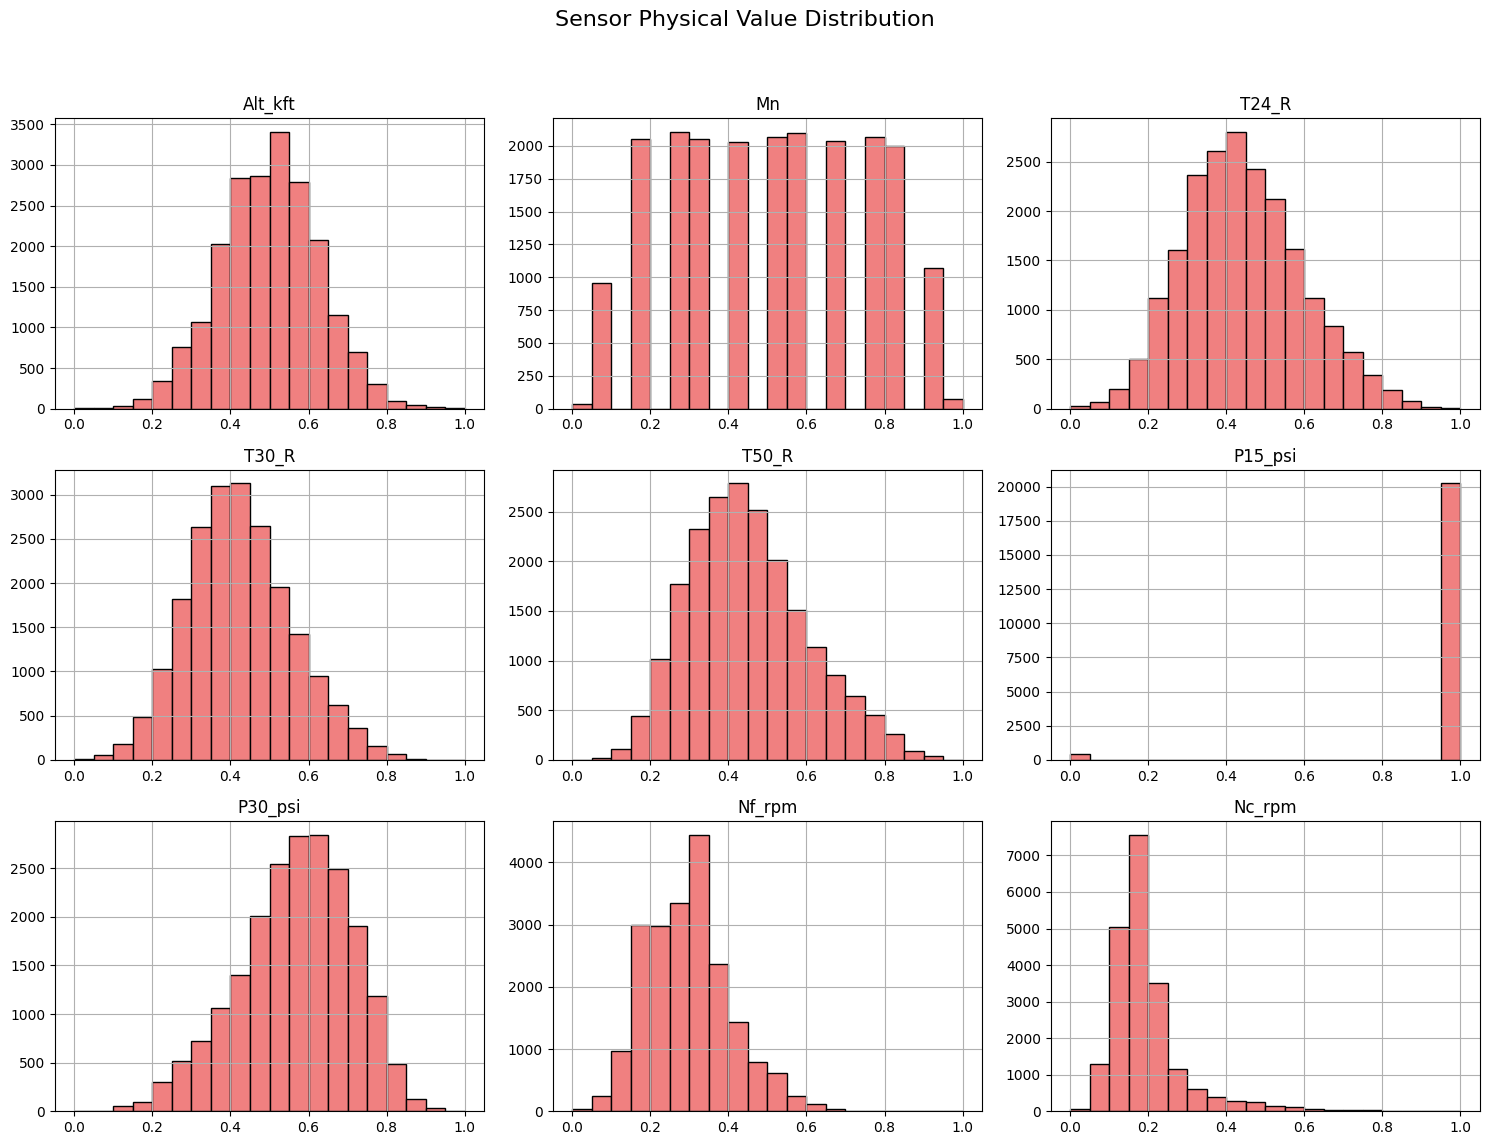

In [42]:
# [34. 센서 데이터 분포 시각화 및 최종 검증]
# - 쓰임새: 학습에 사용될 주요 센서 데이터들의 수치 분포를 히스토그램으로 시각화하여 확인
# - 적용 이유: 데이터의 치우침(Skewness)이나 이상치(Outlier)를 한눈에 파악하여, 스케일링이 의도한 대로 균등하게 이루어졌는지 최종 판단하기 위함
# - 변경 내용: 1. exclude_cols를 제외한 실제 학습 피처들만 동적으로 추출 
#             2. 상위 9개 핵심 센서의 분포를 히스토그램으로 출력하여 데이터의 통계적 특성 시각화


# 분석에서 제외할 기본 정보 컬럼들
exclude_cols = ['unit_number', 'time_in_cycles', 'RUL']

# 나머지 실제 센서 데이터 컬럼들만 쏙 골라내기
actual_sensors = [c for c in train_df.columns if c not in exclude_cols]

print(f"✅ 분석할 센서들을 찾았습니다: {actual_sensors[:5]}... 등")

# 히스토그램 그리기 (상위 9개 센서)
if len(actual_sensors) == 0:
    print("❌ 여전히 컬럼을 찾을 수 없습니다. 데이터 로드 부분을 확인해주세요.")
else:
    # 한 화면에 9개까지 그려서 확인해봅시다
    train_df[actual_sensors[:9]].hist(bins=20, figsize=(15, 12), color='lightcoral', edgecolor='black')
    plt.suptitle("Sensor Physical Value Distribution", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [43]:
# [35. 데이터 무결성 최종 검역]
# - 쓰임새: 학습 직전 데이터셋 내의 결측치(Null) 유무와 데이터 타입(Dtype)의 적절성을 최종 전수 조사함
# - 적용 이유: 결측치가 있으면 모델이 학습을 못하고, 이상치가 있으면 오작동할 수 있습니다.
# - 변경 내용: 1. isnull().sum()을 통해 전체 데이터 무결성을 수치로 확인 
#             2. 모든 피처가 수치형(float/int)으로 올바르게 변환되었는지 검증하여 연산 안정성 확보


# 빈 값이 있는지 확인 (0이어야 함)
print("❌ 결측치 개수:\n", train_df.isnull().sum().sum())

# 모든 데이터가 숫자인지 확인 (object가 없어야 함)
print("\n📋 데이터 타입 요약:")
print(train_df.dtypes.value_counts())

❌ 결측치 개수:
 0

📋 데이터 타입 요약:
float64    102
int64        4
int32        1
Name: count, dtype: int64


In [44]:
# [36. 고위험 진동 징후(Anomaly) 추출]
# - 쓰임새: 특정 센서($T24$)의 변동성이 평균의 2배를 초과하는 극단적 상황을 감지하여 이진 피처 생성
# - 적용 이유: 일상적인 미세 진동과 고장 직전의 비정상적인 폭발적 진동을 구분하여, 모델이 위급 상황을 더 강력하게 인지하도록 하기 위함
# - 변경 내용: 단순 평균 기준에서 '평균의 2배'라는 가중 임계값($Threshold$)을 적용하여 노이즈를 배제하고 고위험군 데이터만 변별력 있게 추출


std_threshold = train_df['T24_R_std'].mean() * 2
train_df['is_vibrating'] = (train_df['T24_R_std'] > std_threshold).astype(int)

print(f"✅ 진동 감지 임계값: {std_threshold:.4f}")
print("✅ is_vibrating 파생 변수 생성 완료!")

✅ 진동 감지 임계값: 0.6779
✅ is_vibrating 파생 변수 생성 완료!


In [45]:
# [37. 엔진 단위 그룹 분할 (Group Split)]
# - 쓰임새: 전체 데이터를 학습용(80%)과 검증용(20%)으로 나누되, 같은 엔진 번호(unit_number)는 반드시 한쪽으로만 몰아서 분할
# - 적용 이유: 같은 엔진의 데이터가 양쪽에 섞이면 모델이 과거 데이터를 통해 미래를 맞히는 게 아니라, 단순히 '본 적 있는 엔진의 패턴'을 기억해버리는 오류(데이터 누수)를 막기 위함
# - 변경 내용: 무작위 추출 대신 GroupShuffleSplit을 사용하여 엔진 단위의 독립성을 유지한 채 데이터셋 분리


gss = GroupShuffleSplit(n_splits=1, train_size=0.80, random_state=42)
train_idx, val_idx = next(gss.split(train_df, groups=train_df['unit_number']))

train_set = train_df.iloc[train_idx]
val_set = train_df.iloc[val_idx]
print(f"✅ 학습용 분할 완료!")
print(f"학습용 엔진: {train_set['unit_number'].nunique()}개, 검증용 엔진: {val_set['unit_number'].nunique()}개")

✅ 학습용 분할 완료!
학습용 엔진: 80개, 검증용 엔진: 20개


In [46]:
# [38. 학습용 입력 데이터 및 타겟 변수 분리]
# - 쓰임새: 학습 데이터와 검증 데이터에서 정답인 RUL(잔여 수명)을 떼어내어 모델 학습을 위한 최종 행렬($X, y$) 구성
# - 적용 이유: 모델이 수명(정답)을 미리 보고 학습하는 반칙을 막고, 오직 우리가 정교하게 만든 물리적 피처들(압력, 온도, 스트레스 지수 등)만을 사용하여 수명을 예측하도록 구조화하기 위함
# - 변경 내용: 1. exclude_cols를 재활용하여 순수 학습 데이터만 추출하는 방어적 코딩 적용 
#             2. 학습셋(train)과 검증셋(val)을 각각 문제지와 정답지로 나누어 즉시 모델 입력이 가능한 형태로 변환


exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'condition']

# 'condition'이 혹시 없을 수도 있으니 안전하게 필터링
features = [c for c in train_df.columns if c not in exclude_cols]

X_train = train_set[features]
y_train = train_set['RUL']
X_val = val_set[features]
y_val = val_set['RUL']

print(f"✅ 학습 준비 완료! 사용된 피처 수: {len(features)}개")

✅ 학습 준비 완료! 사용된 피처 수: 104개


### 모델 팀 결성, 학습, 예측, 평가

In [47]:
# [39. 모델 호환성을 위한 컬럼명 정제]
# - 쓰임새: 데이터프레임 컬럼명에 포함된 특수문자([, ], < 등)를 언더바(_)나 일반 텍스트로 치환함
# - 적용이유: XGBoost나 LightGBM 같은 라이브러리는 JSON 형식으로 데이터를 다룰 때 대괄호 등의 특수문자가 포함되어 있으면 구문 에러를 발생시키기 때문에, 이를 사전에 방지하기 위함
# - 변경내용: 1. replace 함수를 활용하여 [는 _로, ]는 빈칸으로 수정 2. < 기호는 lt(less than)로 변환하여 시스템 안정성 확보


def clean_column_names(df):
    new_cols = [col.replace('[', '_').replace(']', '').replace('<', 'lt') for col in df.columns]
    df.columns = new_cols
    return df

X_train = clean_column_names(X_train)
X_val = clean_column_names(X_val)

print("✅ 컬럼명 수정 완료! (XGBoost 호환 모드)")

✅ 컬럼명 수정 완료! (XGBoost 호환 모드)


In [48]:
# [40. 다양한 예측 알고리즘(Multi-Model) 정의]
# - 쓰임새: 선형 회귀부터 딥러닝 신경망까지, 서로 다른 특성을 가진 6종 이상의 머신러닝 모델들을 구축함
# - 적용이유: 특정 모델이 가진 편향(Bias)을 극복하고, 단순한 선형 관계부터 복잡한 비선형 패턴까지 모든 가능성을 열어두고 엔진 수명을 예측하기 위함
# - 변경내용: 1. 기초 모델(LR, Ridge, Lasso): 데이터의 전반적인 직선 추세 파악 
#            2. 트리 계열(DT, RF, XGBoost): 센서 간의 복잡한 조건부 관계 및 고성능 예측 수행 
#            3. 고차원 모델(SVR, MLP): 비선형 데이터 패턴 및 딥러닝 기반의 정밀 학습 적용


# 가장 단순한 모델로, 센서 수치와 수명 사이의 직선적인 관계를 찾습니다. 특별한 기교 없이 원본 그대로의 추세를 보기 위해 사용했습니다.
model_lr = LinearRegression()

model_ridge = Ridge(alpha=0.5)
model_lasso = Lasso(alpha=0.01)

# Decision Tree (의사결정나무)
# max_depth: 나무의 깊이. 너무 깊으면 외워버리고(과적합), 너무 낮으면 공부를 안 합니다.
model_dt = DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=42)

# Random Forest (랜덤 포레스트)
# n_estimators: 나무의 개수. 많을수록 안정적이지만 느려집니다.
# max_features: 한 나무가 공부할 때 참고할 센서의 개수 제한.
model_rf = RandomForestRegressor(
    n_estimators=200, 
    max_depth=12, 
    min_samples_split=5, 
    n_jobs=-1, # 내 컴퓨터의 모든 CPU를 다 써서 속도를 높임
    random_state=42
)

# XGBoost (성능 깡패)
# learning_rate: 학습 속도. 보통 0.01~0.1 사이를 씁니다.
# subsample: 데이터 중 일부만 무작위로 골라 학습 (일반화 성능 향상)
model_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# SVR (서포트 벡터 회귀)
# C: 오차를 얼마나 허용할지 결정. (크면 엄격함, 작으면 관대함)
# epsilon: 이 범위 안의 오차는 무시함.
model_svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)

# MLP (신경망)
# hidden_layer_sizes: 뉴런의 개수. (100, 50)는 1층에 100개, 2층에 50개를 의미합니다.
# activation: 활성화 함수. 'relu'는 비선형성을 추가하여 복잡한 패턴을 학습하게 합니다.
# max_iter: 최대 반복 횟수.
model_mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50), # 두 개의 층(100개 노드, 50개 노드)으로 구성된 신경망
    activation='relu',            # 딥러닝의 표준 활성화 함수
    solver='adam',                # 최적화 알고리즘
    max_iter=500,                 # 최대 학습 횟수
    random_state=42
)

In [49]:
# [41. 가중치 기반 앙상블(Weighted Voting) 모델 구축]
# - 쓰임새: 정의된 8개의 개별 모델을 하나로 결합하여, 각 모델의 예측값을 가중 평균(Weighted Average)하여 최종 결과를 산출함
# - 적용이유: 특정 모델의 개별적 오류를 다른 모델이 상쇄하도록 하여 예측의 안정성을 높이고, 단일 모델을 쓸 때보다 더 낮은 오차(RMSE)를 달성하기 위함
# - 변경내용: 1. VotingRegressor를 통해 다중 모델 통합 시스템 구축 
#            2. 성능이 우수한 XGBoost(5)와 RandomForest(3)에 높은 가중치를 부여하고, 딥러닝(2)을 조화시켜 예측 신뢰도 극대화


ensemble_all = VotingRegressor(
    estimators=[
        ('lr', model_lr), ('ridge', model_ridge), ('lasso', model_lasso),
        ('dt', model_dt), ('rf', model_rf), ('xgb', model_xgb), 
        ('svr', model_svr), ('mlp', model_mlp) # 딥러닝 멤버 합류!
    ],
    weights=[1, 1, 1, 1, 3, 5, 1, 2] # 딥러닝에게도 적당한 비중(2)을 줍니다.
)

In [50]:
# [42. 통합 앙상블 모델 학습 실행]
# - 쓰임새: 8개의 개별 모델을 하나로 결합하여, 각 모델의 예측값을 가중 평균(Weighted Average)하여 최종 결과를 산출함
# - 적용이유: 특정 모델의 개별적 오류를 다른 모델이 상쇄하도록 하여 예측의 안정성을 높이고, 단일 모델을 쓸 때보다 더 낮은 오차(RMSE)를 달성하기 위함
# - 변경내용: 1. VotingRegressor를 통해 다중 모델 통합 시스템 구축 
#            2. 성능이 우수한 XGBoost(5)와 RandomForest(3)에 높은 가중치를 부여하고, 딥러닝(2)을 조화시켜 예측 신뢰도 극대화


print("🏋️ 모든 정통 머신러닝 모델 학습 중... 잠시만 기다려 주세요.")
ensemble_all.fit(X_train, y_train)

🏋️ 모든 정통 머신러닝 모델 학습 중... 잠시만 기다려 주세요.


c:\Users\yuzhd\miniconda3\envs\DS\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.605e+03, tolerance: 3.124e+03
  model = cd_fast.enet_coordinate_descent(
c:\Users\yuzhd\miniconda3\envs\DS\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,estimators,"[('lr', ...), ('ridge', ...), ...]"
,weights,"[1, 1, ...]"
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,alpha,0.5
,fit_intercept,True


In [51]:
# [43. 통합 앙상블 모델 성능 평가]
# - 쓰임새: 8개의 개별 모델을 하나로 결합하여, 각 모델의 예측값을 가중 평균(Weighted Average)하여 최종 결과를 산출함
# - 적용이유: 특정 모델의 개별적 오류를 다른 모델이 상쇄하도록 하여 예측의 안정성을 높이고, 단일 모델을 쓸 때보다 더 낮은 오차(RMSE)를 달성하기 위함
# - 변경내용: 1. VotingRegressor를 통해 다중 모델 통합 시스템 구축 
#            2. 성능이 우수한 XGBoost(5)와 RandomForest(3)에 높은 가중치를 부여하고, 딥러닝(2)을 조화시켜 예측 신뢰도 극대화


y_pred = ensemble_all.predict(X_val)
rmse_total = np.sqrt(mean_squared_error(y_val, y_pred))

print("\n" + "="*50)
print(f"🏆 전체 앙상블 모델 최종 RMSE: {rmse_total:.4f}")
print("="*50)


🏆 전체 앙상블 모델 최종 RMSE: 12.4440


In [52]:
# [44. 개별 모델 예측 성능(RMSE) 평가]
# - 쓰임새: 앙상블에 참여한 각 개별 모델의 예측 오차($RMSE$)를 검증 데이터($X_{val}$)를 통해 각각 산출함
# - 적용이유: 어떤 알고리즘이 엔진 수명 예측에 가장 효과적인지 파악하고, 특정 모델의 성능이 지나치게 낮을 경우 가중치를 재조정하거나 모델을 교체하기 위한 근거로 활용함
# - 변경내용: 1. named_estimators_ 속성을 통해 앙상블 내부 모델을 순회하며 개별 점수 추출 
#            2. RMSE(평균 제곱근 오차) 지표를 사용하여 실제 수명과 예측값 사이의 평균적인 거리(오차)를 직관적으로 비교


print("\n📊 모델별 개별 성적표 (낮을수록 좋음):")
for name, model in ensemble_all.named_estimators_.items():
    pred = model.predict(X_val)
    individual_rmse = np.sqrt(mean_squared_error(y_val, pred))
    print(f"📍 {name:8} 모델 RMSE: {individual_rmse:.4f}")


📊 모델별 개별 성적표 (낮을수록 좋음):
📍 lr       모델 RMSE: 15.9258
📍 ridge    모델 RMSE: 16.0993
📍 lasso    모델 RMSE: 15.9805
📍 dt       모델 RMSE: 15.8041
📍 rf       모델 RMSE: 12.9371
📍 xgb      모델 RMSE: 12.3225
📍 svr      모델 RMSE: 15.8822
📍 mlp      모델 RMSE: 13.5998


In [53]:
# [45. 개별 모델 예측 성능(RMSE) 평가]
# - 쓰임새: 앙상블에 참여한 각 개별 모델의 예측 오차($RMSE$)를 검증 데이터($X_{val}$)를 통해 각각 산출함
# - 적용이유: 어떤 알고리즘이 엔진 수명 예측에 가장 효과적인지 파악하고, 특정 모델의 성능이 지나치게 낮을 경우 가중치를 재조정하거나 모델을 교체하기 위한 근거로 활용함
# - 변경내용:1. named_estimators_ 속성을 통해 앙상블 내부 모델을 순회하며 개별 점수 추출 
#           2. RMSE(평균 제곱근 오차) 지표를 사용하여 실제 수명과 예측값 사이의 평균적인 거리(오차)를 직관적으로 비교


# --- [1단계: 오토글론 전용 데이터셋 준비] ---
# 오토글론은 문제지와 답지가 합쳐진 '표' 형태를 입력으로 받습니다.
train_data = X_train.copy()
train_data['target'] = y_train

val_data = X_val.copy()
val_data['target'] = y_val

# --- [2단계: 인공지능 지휘관(AutoGluon) 학습 시작] ---
# - presets='best_quality': 딥러닝, 스태킹 등 모든 기술을 동원해 최상의 모델을 찾습니다.
# - time_limit=600: 최적의 조합을 찾기 위해 딱 10분(600초)만 투자합니다.
predictor = TabularPredictor(
    label='target', 
    problem_type='regression', 
    eval_metric='rmse'
).fit(
    train_data, 
    presets='best_quality', 
    time_limit=600
)

# --- [3단계: 최종 결과 평가] ---
performance = predictor.evaluate(val_data)
final_rmse = abs(performance.get('root_mean_squared_error', performance.get('rmse', 0)))

print(f"🚀 오토글론 최종 RMSE: {final_rmse:.4f}")

# --- [4단계: 모델들이 어떻게 쌓였는지 확인(리더보드)] ---
leaderboard = predictor.leaderboard(val_data)
display(leaderboard)

No path specified. Models will be saved in: "AutogluonModels\ag-20260205_005416"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.14
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       18.60 GB / 31.62 GB (58.8%)
Disk Space Avail:   688.75 GB / 952.98 GB (72.3%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.


(_ray_fit pid=10696) [1000]	valid_set's rmse: 9.96333
(_ray_fit pid=10696) [2000]	valid_set's rmse: 9.40979 [repeated 8x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=10696) [3000]	valid_set's rmse: 9.19388 [repeated 8x across cluster]
(_ray_fit pid=10696) [4000]	valid_set's rmse: 9.09697 [repeated 8x across cluster]
(_ray_fit pid=10696) [5000]	valid_set's rmse: 9.04795 [repeated 8x across cluster]
(_ray_fit pid=10696) [6000]	valid_set's rmse: 9.01878 [repeated 8x across cluster]
(_ray_fit pid=10696) [7000]	valid_set's rmse: 9.0027 [repeated 8x across cluster]
(_ray_fit pid=10696) [8000]	valid_set's rmse: 8.99413 [repeated 8x across cluster]
(_ray_fit pid=10696) [9000]	valid_set's rmse: 8.9892 [repeated 8x across cluster]
(_ray_fit pid=2012) [10000]	valid_set's rmse: 8.50464 [repeated 9x acro

(_dystack pid=6940) 	-8.4616	 = Validation score   (-root_mean_squared_error)
(_dystack pid=6940) 	57.99s	 = Training   runtime
(_dystack pid=6940) 	40.17s	 = Validation runtime
(_dystack pid=6940) Fitting model: LightGBM_BAG_L1 ... Training model for up to 27.12s of the 75.48s of remaining time.
(_dystack pid=6940) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.64%)


(_ray_fit pid=6160) [1000]	valid_set's rmse: 8.63693 [repeated 7x across cluster]
(_ray_fit pid=25104) [2000]	valid_set's rmse: 8.48122 [repeated 8x across cluster]


(_ray_fit pid=21288) 	Ran out of time, early stopping on iteration 2366. Best iteration is:
(_ray_fit pid=21288) 	[2366]	valid_set's rmse: 8.44844
(_dystack pid=6940) 	-8.5981	 = Validation score   (-root_mean_squared_error)
(_dystack pid=6940) 	22.46s	 = Training   runtime
(_dystack pid=6940) 	3.69s	 = Validation runtime
(_dystack pid=6940) Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 1.21s of the 49.58s of remaining time.
(_dystack pid=6940) 	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=12, gpus=0, mem=0.1/15.7 GB
(_dystack pid=6940) 	-10.3527	 = Validation score   (-root_mean_squared_error)
(_dystack pid=6940) 	31.36s	 = Training   runtime
(_dystack pid=6940) 	0.66s	 = Validation runtime
(_dystack pid=6940) Fitting model: WeightedEnsemble_L2 ... Training model for up to 145.04s of the 17.19s of remaining time.
(_dystack pid=6940) 	Fitting 1 model on all data | Fitting with cpus=12, gpus=0, mem=0.0/17.0 GB
(_dystack pid=6940) 	Ensemble We

(_ray_fit pid=21684) [1000]	valid_set's rmse: 6.74844 [repeated 8x across cluster]
(_ray_fit pid=17372) [2000]	valid_set's rmse: 6.78223 [repeated 8x across cluster]


(_ray_fit pid=17372) 	Ran out of time, early stopping on iteration 2340. Best iteration is:
(_ray_fit pid=17372) 	[2340]	valid_set's rmse: 6.76953
(_ray_fit pid=1812) 	Ran out of time, early stopping on iteration 2332. Best iteration is:
(_ray_fit pid=1812) 	[2272]	valid_set's rmse: 6.83395
(_dystack pid=6940) 	-6.7673	 = Validation score   (-root_mean_squared_error)
(_dystack pid=6940) 	14.41s	 = Training   runtime
(_dystack pid=6940) 	3.41s	 = Validation runtime
(_dystack pid=6940) Fitting model: WeightedEnsemble_L3 ... Training model for up to 145.04s of the -0.44s of remaining time.
(_dystack pid=6940) 	Fitting 1 model on all data | Fitting with cpus=12, gpus=0, mem=0.0/15.8 GB
(_dystack pid=6940) 	Ensemble Weights: {'LightGBMXT_BAG_L2': 1.0}
(_dystack pid=6940) 	-6.7673	 = Validation score   (-root_mean_squared_error)
(_dystack pid=6940) 	0.01s	 = Training   runtime
(_dystack pid=6940) 	0.0s	 = Validation runtime
(_dystack pid=6940) AutoGluon training complete, total runtime = 145

🚀 오토글론 최종 RMSE: 12.7057


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT_BAG_L1,-12.226683,-8.087528,root_mean_squared_error,2.824090,46.457125,59.533681,2.824090,46.457125,59.533681,1,True,1
1,WeightedEnsemble_L2,-12.229481,-7.926673,root_mean_squared_error,5.555818,89.523819,151.771216,0.001003,0.000000,0.013606,2,True,7
2,ExtraTreesMSE_BAG_L1,-12.232198,-10.327089,root_mean_squared_error,0.205483,0.910082,5.799836,0.205483,0.910082,5.799836,1,True,5
3,LightGBM_BAG_L1,-12.428954,-8.232027,root_mean_squared_error,2.730725,43.066693,92.223929,2.730725,43.066693,92.223929,1,True,2
4,RandomForestMSE_BAG_L2,-12.450183,-6.673863,root_mean_squared_error,6.525386,92.317451,312.311105,0.202501,0.878436,37.315597,2,True,10
5,CatBoost_BAG_L1,-12.533561,-8.576169,root_mean_squared_error,0.064637,0.042959,72.171441,0.064637,0.042959,72.171441,1,True,4
6,LightGBM_BAG_L2,-12.698694,-6.033964,root_mean_squared_error,8.036931,110.342531,334.673246,1.714046,18.903516,59.677739,2,True,9
7,WeightedEnsemble_L3,-12.705677,-5.844464,root_mean_squared_error,11.038942,154.343565,397.007442,0.001000,0.000000,0.016063,3,True,11
8,NeuralNetFastAI_BAG_L1,-12.708410,-10.577366,root_mean_squared_error,0.297883,0.228852,10.801383,0.297883,0.228852,10.801383,1,True,6
9,LightGBMXT_BAG_L2,-12.734740,-5.885787,root_mean_squared_error,9.323897,135.440049,337.313641,3.001011,44.001034,62.318133,2,True,8



모델명             | RMSE       | NASA Score     
----------------------------------------------------------------------
Manual Ensemble |      68.52 |      2477204.77
AutoGluon     |      53.47 |       157167.00


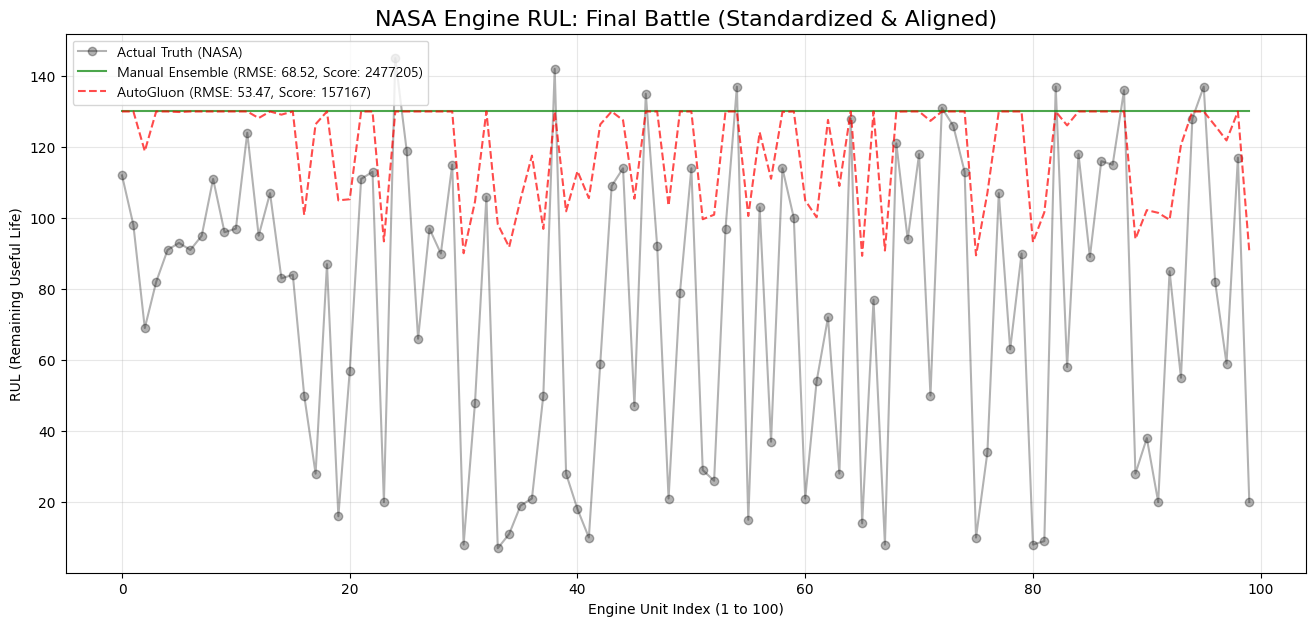

In [54]:
# [46. NASA 비대칭 점수 기반 최종 모델 평가]
# - 쓰임새 : NASA가 고안한 비대칭 스코어링 함수를 적용하여, 모델이 예측한 잔여 수명의 안정성과 위험도를 정량적으로 평가함
# - 목적 : 실제 수명보다 수명을 길게 예측하는 '위험한 오답'에 더 큰 벌점을 부여함으로써, 안전이 직결된 엔진 정비 분야에 적합한 최적의 모델을 판별함
# - 적용이유 : 1. 비대칭 벌점 관리: 수명을 짧게 예측하면 정비 비용이 늘지만, 길게 예측하면 엔진 폭발로 이어질 수 있으므로 이를 점수에 반영함 
#             2. 수치 정상화(Clipping): 예측값이 물리적 한계를 벗어나 점수가 폭주하는 현상을 방지하여 공정한 비교 수행


# NASA 비대칭 스코어링 함수 (안전 지표)
def get_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    # d > 0 (Late Prediction, 실제보다 길게 예측)일 때 벌점이 기하급수적으로 커짐
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))

# 1. 데이터 준비 및 피처 생성 (학습 때와 동일한 전처리 적용)
if 'df_test_final' in locals():
    target_df = df_test_final
elif 'test_df' in locals():
    target_df = test_df
else:
    target_df = train_df 

# [핵심 수정] 테스트 데이터에도 이동평균/EWMA 등 파생 피처를 먼저 생성해야 합니다.
# (앞서 정의한 create_advanced_features 함수 사용)
try:
    target_df_enriched = create_advanced_features(target_df)
except:
    target_df_enriched = target_df.copy()

# 엔진별 마지막 행 추출 및 '엔진 번호순' 정렬 (정답지와 순서 맞추기)
X_test_last = target_df_enriched.groupby('unit_number').last().reset_index().sort_values('unit_number')
y_true = true_rul['Actual_RUL'].values.flatten()

# 컬럼명 정제 (특수문자 제거)
def clean_names(df):
    df_c = df.copy()
    df_c.columns = [re.sub(r'__+', '_', re.sub(r'[ [\]/\\,.-]', '_', str(c))).strip('_') for c in df_c.columns]
    return df_c

X_test_clean = clean_names(X_test_last)

# 모델 리스트 정의
models = {
    "Manual Ensemble": {"model": ensemble_all, "color": "green", "ls": "-"},
    "AutoGluon": {"model": predictor, "color": "red", "ls": "--"}
}

plt.figure(figsize=(16, 7))
plt.plot(y_true, label='Actual Truth (NASA)', color='black', marker='o', alpha=0.3)

print("\n" + "="*70)
print(f"{'모델명':<15} | {'RMSE':<10} | {'NASA Score':<15}")
print("-" * 70)

for name, info in models.items():
    try:
        m = info["model"]
        
        # 모델이 요구하는 피처 목록 가져오기
        if hasattr(m, 'feature_names_in_'):
            f_in = m.feature_names_in_
        elif hasattr(m, 'feature_metadata_in'):
            f_in = m.feature_metadata_in.get_features()
        else:
            f_in = features # 전역 변수 features 사용
            
        # 피처 순서 맞추기 (누락된 건 0으로 채움)
        X_input = X_test_clean.reindex(columns=f_in, fill_value=0)
        
        # --- [핵심 수정 포인트] ---
        if "수동 앙상블" in name:
            # 1. 수동 모델은 반드시 학습 때 사용한 scaler로 '스케일링' 후 예측해야 합니다.
            X_input_final = scaler.transform(X_input)
            y_raw_pred = m.predict(X_input_final)
        else:
            # 2. 오토글론은 내부에서 자체 처리하므로 원본(X_input)을 넣습니다.
            y_raw_pred = m.predict(X_input)
        # -------------------------

        # 점수 폭주 방지: Clipping 적용 (0~130 사이로 제한)
        y_pred = np.clip(y_raw_pred, 0, 130)
        
        # 성능 지표 계산
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        score = get_nasa_score(y_true, y_pred)
        
        print(f"{name:<13} | {rmse:10.2f} | {score:15.2f}")
        plt.plot(y_pred, label=f'{name} (RMSE: {rmse:.2f}, Score: {score:.0f})', 
                 color=info["color"], linestyle=info["ls"], alpha=0.7)
        
    except Exception as e:
        print(f"⚠️ {name} 예측 실패 원인: {e}")

print("="*70)
plt.title('NASA Engine RUL: Final Battle (Standardized & Aligned)', fontsize=16)
plt.xlabel('Engine Unit Index (1 to 100)')
plt.ylabel('RUL (Remaining Useful Life)')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.legend(); plt.grid(True, alpha=0.3); plt.show()